# **Data Investigation**

### **Objectives**

Building upon the initial data understanding completed in the previous notebook, the objective of this notebook is to conduct a detailed variable-level investigation to support the subsequent data cleaning process. Specifically, this notebook aims to:

- Investigate each major variable group individually to understand its characteristics and data quality issues.
- Examine missing-value patterns, structural missingness, inconsistencies, and relationships between variables.
- Identify variable-specific evidence that can support appropriate cleaning decisions.
- Evaluate whether missing values, categorical representations, and numerical values require tailored treatment instead of generic preprocessing rules.
- Document recommended cleaning actions for each variable group while preserving the original dataset without modification.

### Import Library And Loading Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw-data directory: {RAW_DATA_DIR}")
print(f"Processed-data directory: {PROCESSED_DATA_DIR}")

Project root: d:\STUDY\UNF\MDA\term5_capstone_project\assignment\project2
Raw-data directory: d:\STUDY\UNF\MDA\term5_capstone_project\assignment\project2\data\raw
Processed-data directory: d:\STUDY\UNF\MDA\term5_capstone_project\assignment\project2\data\processed


In [3]:
raw_files = list(RAW_DATA_DIR.glob("*"))

if not raw_files:
    print("No raw-data file was found. Add the FAA dataset to data/raw/.")
else:
    for file_path in raw_files:
        print(file_path.name)

faa_strikes.csv


In [4]:
DATA_FILE = RAW_DATA_DIR / "faa_strikes.csv"

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_FILE}\n"
        "Copy the FAA CSV file into the data/raw folder."
    )

df = pd.read_csv(
    DATA_FILE,
    encoding="latin-1",
    low_memory=False
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
df.head()

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,...,NR_INJURIES,NR_FATALITIES,COMMENTS,IMAGE,REPORTED_NAME,REPORTED_TITLE,SOURCE,PERSON,LUPDATE,TRANSFER
0,608407,15/10/1990 00:00:00,10,1990,10:07,Night,KTRI,TRI-CITIES REGIONAL TN/VA ARPT,NaN,NaN,...,NaN,NaN,/Legacy Record 100166/,0,REDACTED,REDACTED,FAA Form 5200-7,NaN,4/12/1998 00:00:00,0
1,608408,7/4/1991 00:00:00,4,1991,NaN,Day,KMDT,HARRISBURG INTL,NaN,NaN,...,NaN,NaN,/Legacy Record 100167/,0,REDACTED,REDACTED,FAA Form 5200-7,Pilot,5/12/1997 00:00:00,0
2,608409,27/10/1991 00:00:00,10,1991,NaN,Day,KLAN,CAPITAL REGION INTL ARPT,NaN,NaN,...,NaN,NaN,/Legacy Record 100168/,0,REDACTED,REDACTED,FAA Form 5200-7,Tower,23/7/1997 00:00:00,0
3,608410,28/5/1990 00:00:00,5,1990,NaN,Day,KMTH,THE FLORIDA KEYS MARATHON,NaN,NaN,...,NaN,NaN,OPER COLUMBUS AVIATION /Legacy Record 100169/,0,REDACTED,REDACTED,FAA Form 5200-7,NaN,8/3/1999 00:00:00,0
4,608411,21/9/1990 00:00:00,9,1990,NaN,Night,KTUL,TULSA INTL,NaN,NaN,...,NaN,NaN,/Legacy Record 100170/,0,REDACTED,REDACTED,FAA Form 5200-7,NaN,31/7/1998 00:00:00,0


# 1. Source and Administrative Variables

This section investigates variables that describe how a wildlife-strike record was reported, submitted, or maintained in the database.

### Investigation questions

1. Do multiple reporting sources and changes in reporting systems over time contribute to data inconsistency or missingness?
2. Does report completeness differ across reporting sources and incident years?
3. Can source-related and temporal patterns provide a logical basis for data-cleaning decisions?

### Variables

- `REPORTED_NAME`, `REPORTED_TITLE`
- `SOURCE`, `PERSON`
- `COMMENTS`, `IMAGE`, `LUPDATE`

The objective is to decide whether each variable should be:

- retained for modelling;
- retained only for descriptive or data-quality analysis;
- investigated further; or
- excluded from the prepared modelling dataset.


In [6]:
source_admin_columns = [
    "REPORTED_NAME",
    "REPORTED_TITLE",
    "SOURCE",
    "PERSON",
    "COMMENTS",
    "IMAGE",
    "LUPDATE"
]

source_admin_overview = pd.DataFrame({
    "Variable": source_admin_columns,
    "Missing_Count": [df[col].isna().sum() for col in source_admin_columns],
    "Missing_Percent": [
        round(df[col].isna().mean() * 100, 2)
        for col in source_admin_columns
    ],
    "Unique_Values": [
        df[col].nunique(dropna=False)
        for col in source_admin_columns
    ]
})

source_admin_overview


,Variable,Missing_Count,Missing_Percent,Unique_Values
0,REPORTED_NAME,0,0.00,1
1,REPORTED_TITLE,0,0.00,1
2,SOURCE,0,0.00,16
3,PERSON,21106,6.06,7
4,COMMENTS,118724,34.10,212200
5,IMAGE,0,0.00,2
6,LUPDATE,0,0.00,4834


## 1.1 Redacted reporter information

`REPORTED_NAME` and `REPORTED_TITLE` describe the person filing the report.  
Before making a decision, verify whether the fields contain usable variation.


In [7]:
reported_fields_summary = pd.DataFrame({
    "Variable": ["REPORTED_NAME", "REPORTED_TITLE"],
    "Unique_Values": [
        df["REPORTED_NAME"].nunique(dropna=False),
        df["REPORTED_TITLE"].nunique(dropna=False)
    ],
    "Most_Common_Value": [
        df["REPORTED_NAME"].value_counts(dropna=False).index[0],
        df["REPORTED_TITLE"].value_counts(dropna=False).index[0]
    ],
    "Most_Common_Count": [
        df["REPORTED_NAME"].value_counts(dropna=False).iloc[0],
        df["REPORTED_TITLE"].value_counts(dropna=False).iloc[0]
    ]
})

reported_fields_summary


,Variable,Unique_Values,Most_Common_Value,Most_Common_Count
0,REPORTED_NAME,1,REDACTED,348146
1,REPORTED_TITLE,1,REDACTED,348146


### Decision

Both fields are fully redacted and have no usable variation.

- **Further investigation:** Not required.
- **Prepared modelling dataset:** Drop both variables.
- **Reason:** Personally identifiable administrative information with no analytical or predictive value.


## 1.2 Reporting source and reporter category

`SOURCE` identifies the reporting form or system.  
`PERSON` identifies the person or operational group associated with reporting or detecting the event.

These variables may help explain differences in data collection, but they describe the reporting process rather than the physical conditions of the strike.


In [8]:
def categorical_summary(data, column):
    summary = (
        data[column]
        .fillna("Missing")
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="Count")
    )
    summary["Percentage"] = (
        summary["Count"] / len(data) * 100
    ).round(2)
    return summary

source_summary = categorical_summary(df, "SOURCE")
person_summary = categorical_summary(df, "PERSON")

display(source_summary)
display(person_summary)


,SOURCE,Count,Percentage
0,FAA Form 5200-7-E,216344,62.14
1,FAA Form 5200-7,41782,12.00
2,Multiple,40229,11.56
3,MOR,17899,5.14
4,Air Transport Report,17182,4.94
5,Airport Report,7335,2.11
6,Other,2340,0.67
7,Daily Report,2182,0.63
8,PACIR,879,0.25
9,Engine Manufacturer,810,0.23


,PERSON,Count,Percentage
0,Carcass Found,95738,27.50
1,Airport Operations,85056,24.43
2,Pilot,63907,18.36
3,Tower,36430,10.46
4,Air Transport Operations,35529,10.21
5,Missing,21106,6.06
6,Other,10380,2.98


### Reporting systems over time

A 100% stacked bar chart is used because the number of reports changes substantially across years.  
The chart focuses on changes in the proportion of records originating from each source.


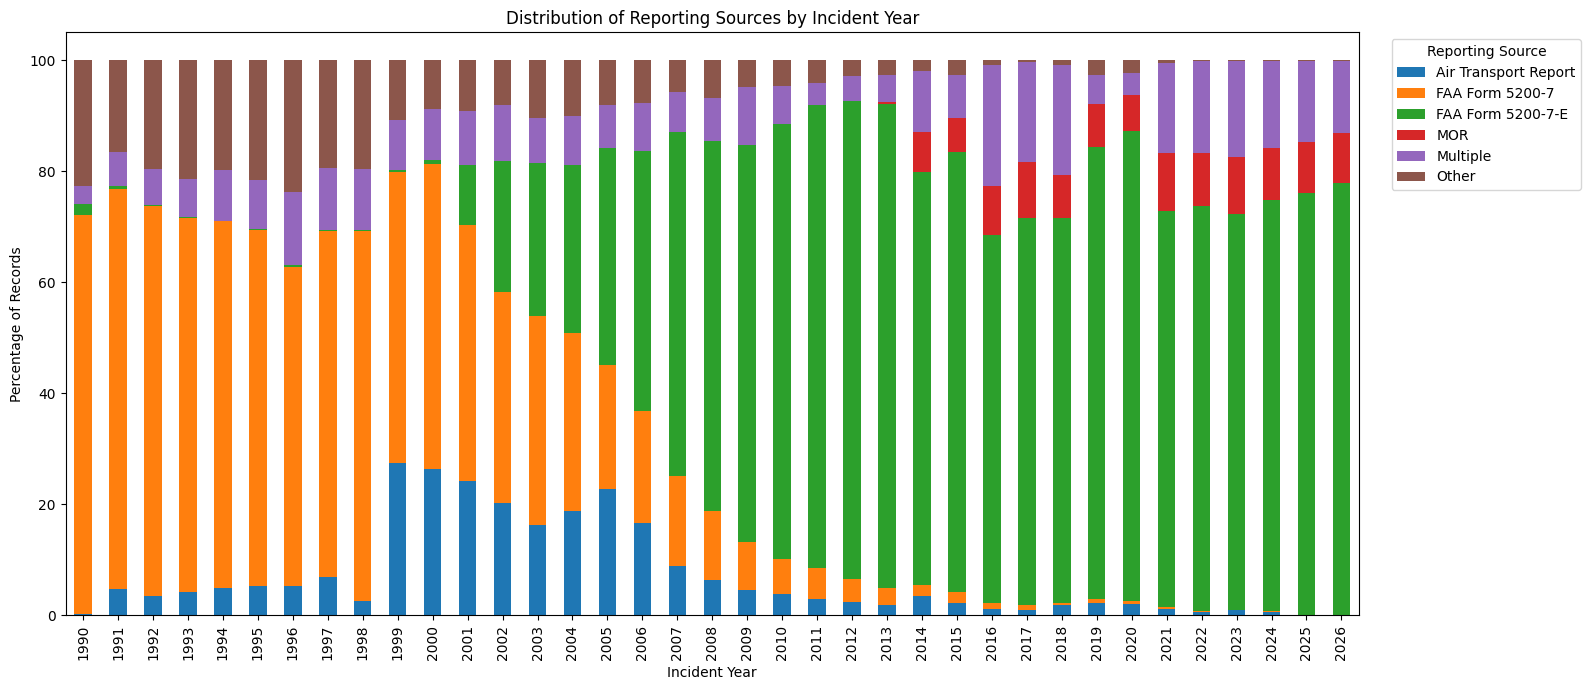

In [9]:
top_sources = df["SOURCE"].value_counts().head(5).index

source_plot = df[["INCIDENT_YEAR", "SOURCE"]].copy()
source_plot["SOURCE_GROUPED"] = source_plot["SOURCE"].where(
    source_plot["SOURCE"].isin(top_sources),
    "Other"
)

source_by_year_pct = (
    pd.crosstab(
        source_plot["INCIDENT_YEAR"],
        source_plot["SOURCE_GROUPED"],
        normalize="index"
    ) * 100
)

source_by_year_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 7)
)

plt.title("Distribution of Reporting Sources by Incident Year")
plt.xlabel("Incident Year")
plt.ylabel("Percentage of Records")
plt.legend(
    title="Reporting Source",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()


### Interim finding

The dominant reporting source changes substantially over time. This confirms that the dataset combines records collected under different reporting systems and historical procedures.

This pattern is useful for:

- identifying possible temporal reporting bias;
- assessing whether older and newer records are directly comparable;
- supporting the selection of a modelling period.

However, it does not by itself prove that one reporting source produces higher-quality reports.


## 1.3 Report completeness by source and year

To evaluate whether reporting systems are associated with data completeness, calculate a record-level completeness score using selected operational fields.

The score measures the percentage of selected fields that are non-missing. It is an analytical indicator, not a definitive measure of overall report quality.


In [10]:
quality_columns = [
    "TIME",
    "TIME_OF_DAY",
    "PHASE_OF_FLIGHT",
    "HEIGHT",
    "SPEED",
    "SKY",
    "PRECIPITATION",
    "SIZE",
    "NUM_SEEN",
    "NUM_STRUCK",
    "INDICATED_DAMAGE"
]

df_quality = df.copy()

df_quality["COMPLETENESS_RATE"] = (
    df_quality[quality_columns]
    .notna()
    .mean(axis=1)
    .mul(100)
)


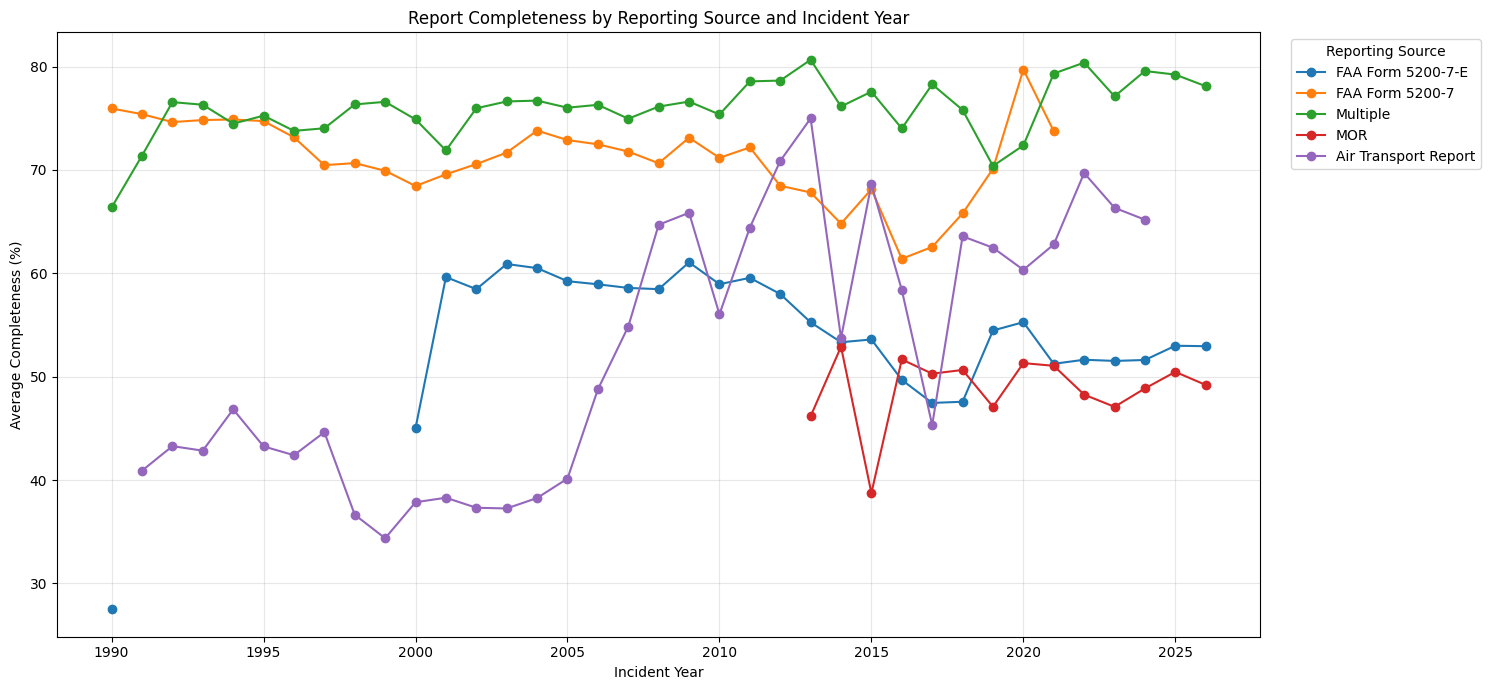

In [11]:
quality_by_year_source = (
    df_quality
    .groupby(["INCIDENT_YEAR", "SOURCE"])
    .agg(
        Records=("INDEX_NR", "size"),
        Average_Completeness=("COMPLETENESS_RATE", "mean")
    )
    .reset_index()
)

# Avoid unstable yearly averages based on very small groups.
quality_by_year_source_filtered = quality_by_year_source[
    quality_by_year_source["Records"] >= 30
]

quality_pivot = quality_by_year_source_filtered.pivot(
    index="INCIDENT_YEAR",
    columns="SOURCE",
    values="Average_Completeness"
)

top_sources = df["SOURCE"].value_counts().head(5).index
quality_pivot_top = quality_pivot[
    [source for source in top_sources if source in quality_pivot.columns]
]

quality_pivot_top.plot(
    figsize=(15, 7),
    marker="o"
)

plt.title("Report Completeness by Reporting Source and Incident Year")
plt.xlabel("Incident Year")
plt.ylabel("Average Completeness (%)")
plt.legend(
    title="Reporting Source",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Interpretation and decision

Report completeness differs across reporting sources and years, indicating that missingness is associated with the reporting process. However, the pattern is not consistently improving over time, and newer reporting systems do not always produce more complete records.

Therefore:

- **Use for data-quality assessment:** Yes.
- **Use for automatic imputation:** No. No stable source-specific rule was identified.
- **Use for selecting a modelling period:** Potentially yes; investigate missingness of individual core predictors by period before choosing a cutoff year.
- **Use in the primary predictive model:** Exclude `SOURCE` and `PERSON`, because they describe the reporting process rather than strike conditions.
- **Further investigation:** Only if period selection requires comparison of specific predictor missingness before and after a candidate cutoff year.


## 1.4 Free-text and database-maintenance fields

`COMMENTS` contains database-manager notes, corrections, assumptions, legacy references, record merges, and potentially identifying information.

`IMAGE` records image availability rather than strike conditions.

`LUPDATE` is the database record's last-update timestamp.


In [12]:
text_admin_summary = pd.DataFrame({
    "Variable": ["COMMENTS", "IMAGE", "LUPDATE"],
    "Missing_Percent": [
        round(df[col].isna().mean() * 100, 2)
        for col in ["COMMENTS", "IMAGE", "LUPDATE"]
    ],
    "Unique_Values": [
        df[col].nunique(dropna=False)
        for col in ["COMMENTS", "IMAGE", "LUPDATE"]
    ],
    "Example": [
        df[col].dropna().astype(str).iloc[0]
        if df[col].notna().any() else None
        for col in ["COMMENTS", "IMAGE", "LUPDATE"]
    ]
})

text_admin_summary


,Variable,Missing_Percent,Unique_Values,Example
0,COMMENTS,34.1,212200,/Legacy Record 100166/
1,IMAGE,0.0,2,0
2,LUPDATE,0.0,4834,4/12/1998 00:00:00


### Decisions
| Variable   | Final use                    | Decision rationale                                                                                                                                                                                      |
| ---------- | ---------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `COMMENTS` | Raw-data audit only          | High-cardinality administrative free text containing corrections, assumptions, legacy references, and database-maintenance notes. NLP is outside the project scope and the field may introduce leakage. |
| `IMAGE`    | Data-quality assessment only | Binary indicator of image availability. It may reflect reporting completeness, but it does not directly describe strike conditions. Investigate briefly before excluding it from the primary model.     |
| `LUPDATE`  | Drop from modelling          | Post-incident database-update timestamp that reflects maintenance or processing activity rather than strike conditions and may introduce temporal leakage.                                              |


## 1.5 Data Cleaning Decisions for Sources Variables

| Variable(s)                       | Role                                |         Primary model | Other use                                 | Further investigation                                    |
| --------------------------------- | ----------------------------------- | --------------------: | ----------------------------------------- | -------------------------------------------------------- |
| `REPORTED_NAME`, `REPORTED_TITLE` | Redacted administrative information |                  Drop | None                                      | No                                                       |
| `SOURCE`                          | Reporting-system provenance         |               Exclude | Data-quality and temporal-bias assessment | Only for modelling-period selection                      |
| `PERSON`                          | Reporter/detection category         |               Exclude | Descriptive reporting-bias assessment     | No, unless specifically required                         |
| `COMMENTS`                        | Free-text database notes            |               Exclude | Raw-data audit                            | Only for individual anomalies                            |
| `IMAGE`                           | Attachment-availability indicator   | Exclude provisionally | Data-quality assessment                   | Briefly assess its relationship with report completeness |
| `LUPDATE`                         | Database update metadata            |                  Drop | Raw-data audit only                       | No                                                       |


### Section conclusion

The dataset combines records from multiple reporting systems whose use changes over time. Report completeness also varies across reporting sources and incident years, suggesting that historical reporting practices are associated with differences in data quality. However, no stable source-based pattern was identified that would support automatic correction or imputation. Therefore, source and administrative variables will be used to support data-quality assessment, temporal-bias evaluation, and possible modelling-period selection, but they will not be included in the primary predictive feature set.


# 2. Temporal Variables

### Investigation Questions
Are there any anomalies or inconsistencies in the temporal variables, and how should they be handled?

### Variables

- INCIDENT_DATE
- INCIDENT_MONTH
- INCIDENT_YEAR
- TIME_OF_DAY
- TIME


In [13]:
source_time_columns = [
    "INCIDENT_DATE",
    "INCIDENT_MONTH",
    "INCIDENT_YEAR",
    "TIME_OF_DAY",
    "TIME"
]
source_time_overview = pd.DataFrame({
    "Variable": source_time_columns,

    "Data_Type": [
        str(df[col].dtype)
        for col in source_time_columns
    ],

    "Missing_Count": [
        df[col].isna().sum()
        for col in source_time_columns
    ],

    "Blank_Count": [
        (
            df[col].astype("string").str.strip().eq("")
        ).sum()
        for col in source_time_columns
    ],

    "Effective_Missing_Count": [
        (
            df[col].isna()
            | df[col].astype("string").str.strip().eq("")
        ).sum()
        for col in source_time_columns
    ],

    "Effective_Missing_Percent": [
        round(
            (
                df[col].isna()
                | df[col].astype("string").str.strip().eq("")
            ).mean() * 100,
            2
        )
        for col in source_time_columns
    ],

    "Unique_Values": [
        df[col].nunique(dropna=False)
        for col in source_time_columns
    ],

    "Example_Values": [
        df[col]
        .dropna()
        .astype(str)
        .str.strip()
        .loc[lambda x: x.ne("")]
        .drop_duplicates()
        .head(5)
        .tolist()
        for col in source_time_columns
    ]
})

source_time_overview

,Variable,Data_Type,Missing_Count,Blank_Count,Effective_Missing_Count,Effective_Missing_Percent,Unique_Values,Example_Values
0,INCIDENT_DATE,object,0,0,0,0.00,13223,"[15/10/1990 00:00:00, 7/4/1991 00:00:00, 27/10..."
1,INCIDENT_MONTH,int64,0,0,0,0.00,12,"[10, 4, 5, 9, 8]"
2,INCIDENT_YEAR,int64,0,0,0,0.00,37,"[1990, 1991, 1992, 1995, 1993]"
3,TIME_OF_DAY,object,151729,0,151729,43.58,5,"[Night, Day, Dawn, Dusk]"
4,TIME,object,121363,28297,149660,42.99,1442,"[10:07, 10:00, 19:05, 11:30, 19:18]"


- Convert INCIDENT_DATE from object to datetime.
- Check whether INCIDENT_MONTH and INCIDENT_YEAR match the month and year extracted from INCIDENT_DATE.
- Check TIME_OF_DAY for unexpected categories and determine an appropriate method for handling missing values.
- Treat blank values in TIME as missing and validate whether the remaining values are logically and format-wise valid.

## 2.2 Date, Month, Year

In [14]:
date_parsed = pd.to_datetime(df["INCIDENT_DATE"], errors="coerce")

date_check = pd.DataFrame({
    "INCIDENT_DATE": df["INCIDENT_DATE"],
    "INCIDENT_MONTH": df["INCIDENT_MONTH"],
    "INCIDENT_YEAR": df["INCIDENT_YEAR"],
    "MONTH_FROM_DATE": date_parsed.dt.month,
    "YEAR_FROM_DATE": date_parsed.dt.year
})

date_check["MONTH_MATCH"] = (
    date_check["INCIDENT_MONTH"] == date_check["MONTH_FROM_DATE"]
)

date_check["YEAR_MATCH"] = (
    date_check["INCIDENT_YEAR"] == date_check["YEAR_FROM_DATE"]
)

print("Month mismatches:", (~date_check["MONTH_MATCH"]).sum())
print("Year mismatches:", (~date_check["YEAR_MATCH"]).sum())
print("Month range:", df["INCIDENT_MONTH"].min(), "-", df["INCIDENT_MONTH"].max())
print("Year range:", df["INCIDENT_YEAR"].min(), "-", df["INCIDENT_YEAR"].max())

Month mismatches: 0
Year mismatches: 0
Month range: 1 - 12
Year range: 1990 - 2026


C:\Users\Admin\AppData\Local\Temp\ipykernel_30428\313282088.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  date_parsed = pd.to_datetime(df["INCIDENT_DATE"], errors="coerce")


In [15]:
date_anomalies = date_check[
    (~date_check["MONTH_MATCH"])
    | (~date_check["YEAR_MATCH"])
    | (~df["INCIDENT_MONTH"].between(1, 12))
]

date_anomalies.head(20)

,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,MONTH_FROM_DATE,YEAR_FROM_DATE,MONTH_MATCH,YEAR_MATCH


The date, month, and year values are consistent, with no anomalies identified

## 2.3 TIME_OF_DAY

In [16]:
valid_time_of_day = {"Dawn", "Day", "Dusk", "Night"}

observed_categories = set(
    df["TIME_OF_DAY"].dropna().astype(str).str.strip().unique()
)

unexpected_categories = observed_categories - valid_time_of_day

print("Observed categories:", observed_categories)
print("Unexpected categories:", unexpected_categories)

Observed categories: {'Dusk', 'Night', 'Day', 'Dawn'}
Unexpected categories: set()


In [17]:
df["TIME_OF_DAY"].value_counts(dropna=False)

TIME_OF_DAY
NaN      151729
Day      119566
Night     61522
Dusk       8620
Dawn       6709
Name: count, dtype: int64

No anomalies were identified; only missing values are present. Since TIME_OF_DAY represents lighting conditions, it cannot be reliably derived from the TIME column. Missing values should therefore be filled with Unknown.

## 2.3 TIME

In [18]:
#Check whether the values follow the local time format HH:MM

time_clean = df["TIME"].astype("string").str.strip()

time_parsed = pd.to_datetime(
    time_clean,
    format="%H:%M",
    errors="coerce"
)

invalid_time = (
    time_clean.notna()
    & time_clean.ne("")
    & time_parsed.isna()
)

print("Invalid non-missing TIME values:", invalid_time.sum())

Invalid non-missing TIME values: 0


In [19]:
df.loc[invalid_time, "TIME"].value_counts().head(20)

Series([], Name: count, dtype: int64)

In [20]:
print("Earliest valid time:", time_parsed.min())
print("Latest valid time:", time_parsed.max())

Earliest valid time: 1900-01-01 00:00:00
Latest valid time: 1900-01-01 23:59:00


- Convert blank values to missing values.
- No invalid non-missing TIME values were identified.
- Missing values should not be imputed using the mean, median, or mode.
- If needed for modelling, valid time values can be transformed into hour, time_sin, and time_cos features.

## 2.4. Data Cleaning Decisions for Temporal Variables

| Column           | Finding                              | Treatment                                                |
| ---------------- | ------------------------------------ | -------------------------------------------------------- |
| `INCIDENT_DATE`  | No anomalies                         | Convert to `datetime`                                    |
| `INCIDENT_MONTH` | Matches `INCIDENT_DATE`              | Retain                                                   |
| `INCIDENT_YEAR`  | Matches `INCIDENT_DATE`              | Retain                                                   |
| `TIME_OF_DAY`    | No anomalies; missing values present | Fill missing with `Unknown`                              |
| `TIME`           | Valid `HH:MM`; blanks present        | Blank -> missing; consider `hour`, `time_sin`, `time_cos` |


# 3. Location Variables

In [21]:
source_location_columns = [
    "AIRPORT_ID",
    "AIRPORT",
    "AIRPORT_LATITUDE",
    "AIRPORT_LONGITUDE",
    "INCIDENT_LATITUDE",
    "INCIDENT_LONGITUDE",
    "RUNWAY",
    "STATE",
    "FAAREGION",
    "LOCATION",
    "ENROUTE_STATE"
]

source_location_overview = pd.DataFrame({
    "Variable": source_location_columns,

    "Data_Type": [
        str(df[col].dtype)
        for col in source_location_columns
    ],

    "Missing_Count": [
        df[col].isna().sum()
        for col in source_location_columns
    ],

    "Blank_Count": [
        df[col]
        .astype("string")
        .str.strip()
        .eq("")
        .sum()
        for col in source_location_columns
    ],

    "Effective_Missing_Count": [
        (
            df[col].isna()
            | df[col].astype("string").str.strip().eq("")
        ).sum()
        for col in source_location_columns
    ],

    "Effective_Missing_Percent": [
        round(
            (
                df[col].isna()
                | df[col].astype("string").str.strip().eq("")
            ).mean() * 100,
            2
        )
        for col in source_location_columns
    ],

    "Unique_Values": [
        df[col].nunique(dropna=False)
        for col in source_location_columns
    ],

    "Example_Values": [
        df[col]
        .dropna()
        .astype(str)
        .str.strip()
        .loc[lambda x: x.ne("")]
        .drop_duplicates()
        .head(5)
        .tolist()
        for col in source_location_columns
    ]
})

source_location_overview

,Variable,Data_Type,Missing_Count,Blank_Count,Effective_Missing_Count,Effective_Missing_Percent,Unique_Values,Example_Values
0,AIRPORT_ID,object,0,0,0,0.00,2779,"[KTRI, KMDT, KLAN, KMTH, KTUL]"
1,AIRPORT,object,0,0,0,0.00,2779,"[TRI-CITIES REGIONAL TN/VA ARPT, HARRISBURG IN..."
2,AIRPORT_LATITUDE,float64,348146,0,348146,100.00,1,[]
3,AIRPORT_LONGITUDE,float64,348146,0,348146,100.00,1,[]
4,INCIDENT_LATITUDE,float64,348146,0,348146,100.00,1,[]
5,INCIDENT_LONGITUDE,float64,348146,0,348146,100.00,1,[]
6,RUNWAY,object,85954,0,85954,24.69,1561,"[23, 31, 32, 5, 11L]"
7,STATE,object,46930,0,46930,13.48,68,"[TN, PA, MI, FL, OK]"
8,FAAREGION,object,46930,0,46930,13.48,11,"[ASO, AEA, AGL, ASW, ANE]"
9,LOCATION,object,302921,4,302925,87.01,10214,"[FOUND AT KORD, FOUND AT KBTR, 19 SE WATERTOWN..."


- AIRPORT_LATITUDE, AIRPORT_LONGITUDE: Recover by mapping AIRPORT_ID to an external airport reference dataset.
- INCIDENT_LATITUDE, INCIDENT_LONGITUDE: Drop due to 100% missing values and no reliable recovery source.
- LOCATION: Retain for descriptive analysis only. Fill missing values with Unknown because it is an unstructured text field with high missingness.
- RUNWAY: Treat as a categorical variable. Fill missing values with Unknown.
- STATE, FAAREGION, ENROUTE_STATE: Investigate their missing-value patterns and relationship with PHASE_OF_FLIGHT. If appropriate, create a unified location variable using STATE and ENROUTE_STATE.

## 3.1 STATE, ENROUTE STATE AND FAAREGION

In [22]:
# Kiểm tra missing theo PHASE_OF_FLIGHT
pd.crosstab(
    df["PHASE_OF_FLIGHT"],
    df["ENROUTE_STATE"].notna(),
    normalize="index"
).round(3)

ENROUTE_STATE,False,True
PHASE_OF_FLIGHT,,
Approach,0.999,0.001
Arrival,1.000,0.000
Climb,0.999,0.001
Departure,1.000,0.000
Descent,1.000,0.000
En Route,0.097,0.903
Landing Roll,1.000,0.000
Local,0.990,0.010
Parked,0.974,0.026


ENROUTE_STATE is populated mainly for en-route incidents (90.3%) and is nearly always missing for other flight phases, indicating that most missing values are structurally related to the flight phase.

In [23]:
pd.crosstab(
    df["PHASE_OF_FLIGHT"],
    df["STATE"].notna(),
    normalize="index"
).round(3)

STATE,False,True
PHASE_OF_FLIGHT,,
Approach,0.003,0.997
Arrival,0.001,0.999
Climb,0.005,0.995
Departure,0.002,0.998
Descent,0.008,0.992
En Route,1.000,0.000
Landing Roll,0.002,0.998
Local,0.029,0.971
Parked,0.207,0.793


STATE is available for almost all non-en-route incidents (97–100%), but is completely missing for en-route incidents. This indicates that STATE is primarily used to identify airport-related incidents rather than en-route events.

Or another words, STATE and ENROUTE_STATE exhibit complementary missing-value patterns. STATE is populated for airport-related flight phases, whereas ENROUTE_STATE is primarily populated for en-route incidents.

=> A unified INCIDENT_STATE variable can be created by combining STATE and ENROUTE_STATE, since the two variables describe the incident location under different flight phases.

In [24]:
# Kiểm tra STATE và ENROUTE_STATE có đồng thời xuất hiện không
pd.crosstab(
    df["STATE"].notna(),
    df["ENROUTE_STATE"].notna()
)

ENROUTE_STATE,False,True
STATE,,
False,40888,6042
True,301214,2


STATE and ENROUTE_STATE are almost mutually exclusive. Most records contain either STATE or ENROUTE_STATE, while only two records contain both variables. Therefore, the two variables can be combined into a unified INCIDENT_STATE variable.

In [25]:
# Mapping between 2 variables

df.loc[
    df["STATE"].notna() & df["FAAREGION"].notna(),
    ["STATE", "FAAREGION"]
].drop_duplicates().sort_values(["STATE", "FAAREGION"])

,STATE,FAAREGION
216,AB,FGN
309,AK,AAL
9,AL,ASO
31,AR,ASW
12964,AS,AWP
...,...,...
1793,VT,ANE
8,WA,ANM
220,WI,AGL
258,WV,AEA


In [26]:
df.groupby("STATE")["FAAREGION"].nunique().sort_values(ascending=False)

STATE
AB    1
PR    1
ND    1
NE    1
NH    1
     ..
MH    1
MI    1
MN    1
MO    1
WY    1
Name: FAAREGION, Length: 67, dtype: int64

STATE and FAAREGION show a consistent one-to-one mapping, suggesting that missing FAAREGION values can be inferred from STATE when available.

## 3.2 Data Cleaning Decisions for Location Variables

| Column                                    | Finding                                                                                                                                                                        | Treatment                                                                                   |
| ----------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | ------------------------------------------------------------------------------------------- |
| `AIRPORT_LATITUDE`, `AIRPORT_LONGITUDE`   | Both columns are 100% missing, but airport coordinates may be recovered using `AIRPORT_ID`.                                                                                    | Recover from an external airport reference dataset using `AIRPORT_ID`.                      |
| `INCIDENT_LATITUDE`, `INCIDENT_LONGITUDE` | Both columns are 100% missing and cannot be reliably recovered.                                                                                                                | Drop both columns.                                                                          |
| `LOCATION`                                | Unstructured text with approximately 87% missing values.                                                                                                                       | Fill missing values with `Unknown` and retain for descriptive analysis only.                |
| `RUNWAY`                                  | Categorical runway identifier with approximately 25% missing values.                                                                                                           | Standardize as text and fill missing values with `Unknown`.                                 |
| `STATE`, `ENROUTE_STATE`                  | The two columns have complementary missing patterns. `STATE` is mainly available for non-en-route incidents, while `ENROUTE_STATE` is mainly available for en-route incidents. | Create `INCIDENT_STATE` using `STATE` first, then fill missing values with `ENROUTE_STATE`. |
| `FAAREGION`                               | Each `STATE` is consistently associated with one FAA region.                                                                                                                   | Recover missing values using a validated state-to-FAA-region mapping.                       |


# 4. Flight Information Variables

## 4.1 Overview of Flight Information Variables

In [27]:
flight_information_columns = [
    "OPID",
    "OPERATOR",
    "FLT",
    "PHASE_OF_FLIGHT",
    "HEIGHT",
    "SPEED",
    "DISTANCE"
]

flight_information_overview = pd.DataFrame({
    "Variable": flight_information_columns,

    "Data_Type": [
        str(df[col].dtype)
        for col in flight_information_columns
    ],

    "Missing_Count": [
        df[col].isna().sum()
        for col in flight_information_columns
    ],

    "Blank_Count": [
        df[col]
        .astype("string")
        .str.strip()
        .eq("")
        .sum()
        for col in flight_information_columns
    ],

    "Effective_Missing_Count": [
        (
            df[col].isna()
            | df[col].astype("string").str.strip().eq("")
        ).sum()
        for col in flight_information_columns
    ],

    "Effective_Missing_Percent": [
        round(
            (
                df[col].isna()
                | df[col].astype("string").str.strip().eq("")
            ).mean() * 100,
            2
        )
        for col in flight_information_columns
    ],

    "Unique_Values": [
        df[col].nunique(dropna=False)
        for col in flight_information_columns
    ],

    "Example_Values": [
        df[col]
        .dropna()
        .astype(str)
        .str.strip()
        .loc[lambda x: x.ne("")]
        .drop_duplicates()
        .head(5)
        .tolist()
        for col in flight_information_columns
    ]
})

flight_information_overview

,Variable,Data_Type,Missing_Count,Blank_Count,Effective_Missing_Count,Effective_Missing_Percent,Unique_Values,Example_Values
0,OPID,object,3,0,3,0.00,632,"[NAE, AAL, SYM, BUS, USA]"
1,OPERATOR,object,1,0,1,0.00,626,"[NASHVILLE EAGLE, AMERICAN AIRLINES, SIMMONS A..."
2,FLT,object,181341,3,181344,52.09,11797,"[48, 1851, 1768, 1845, 306]"
3,PHASE_OF_FLIGHT,object,137169,0,137169,39.40,13,"[Approach, Landing Roll, Climb, Take-off Run, ..."
4,HEIGHT,float64,175165,0,175165,50.31,762,"[1500.0, 0.0, 75.0, 4000.0, 3000.0]"
5,SPEED,float64,240498,0,240498,69.08,293,"[160.0, 120.0, 130.0, 180.0, 95.0]"
6,DISTANCE,float64,117493,0,117493,33.75,258,"[0.0, 8.0, 9.0, 0.5, 20.0]"


OPID and FLT are identifier variables with no analytical value for predictive modelling. Although both variables contain a small number of missing values, they will be removed during feature selection and therefore require no imputation or additional cleaning. 

In contrast, OPERATOR, PHASE_OF_FLIGHT, HEIGHT, SPEED, and DISTANCE are retained for analysis and contain varying levels of missingness. The following investigation focuses on assessing data quality, missing-value patterns, category consistency, and numerical anomalies for these variables.

## 4.2 OPERATOR 

In [28]:
# Display records where OPID or OPERATOR is missing
df.loc[
    df["OPID"].isna() | df["OPERATOR"].isna(),
    ["OPID", "OPERATOR"]
]

,OPID,OPERATOR
345476,NaN,NaN
345497,NaN,Humboldt County Aviation Department
347469,NaN,Memorial Hermann Life Flight


OPERATOR has only one missing record. This value can be labelled as Unknown.

## 4.3 Investigation of Flight Phase and Numerical Flight Variables
This section reviews `PHASE_OF_FLIGHT`, `HEIGHT`, `SPEED`, and `DISTANCE`.

The investigation focuses on:

- Category consistency in `PHASE_OF_FLIGHT`
- Missing-value patterns
- Relationships between flight phase and numerical flight variables
- Negative or impossible numerical values
- Potential outliers
- Appropriate cleaning treatments

In [29]:
phase_numeric_missing = (
    df.groupby("PHASE_OF_FLIGHT")[["HEIGHT", "SPEED", "DISTANCE"]]
      .apply(lambda x: (x.isna().mean() * 100).round(2))
)

phase_numeric_missing.columns = [
    "HEIGHT_Missing_Percent",
    "SPEED_Missing_Percent",
    "DISTANCE_Missing_Percent"
]

phase_numeric_missing

,HEIGHT_Missing_Percent,SPEED_Missing_Percent,DISTANCE_Missing_Percent
PHASE_OF_FLIGHT,,,
Approach,25.46,40.54,53.40
Arrival,99.56,99.39,51.88
Climb,21.82,36.63,52.83
Departure,99.83,99.68,64.12
Descent,41.16,52.85,68.50
En Route,18.49,26.55,99.91
Landing Roll,0.00,64.29,0.00
Local,68.89,81.86,31.57
Parked,0.00,66.38,0.00


Missingness in `HEIGHT`, `SPEED`, and `DISTANCE` varies considerably across flight phases.

Ground phases such as `Landing Roll`, `Parked`, `Take-off Run`, and `Taxi` have complete `HEIGHT` and `DISTANCE` values, while `SPEED` is still frequently missing.

For airborne phases, the three variables contain substantial and inconsistent missingness. In particular, `Arrival` and `Departure` are almost entirely missing `HEIGHT` and `SPEED`, while `En Route` is almost entirely missing `DISTANCE`.

Therefore, these numerical variables are not recorded consistently enough to reliably infer missing `PHASE_OF_FLIGHT` values. The investigation of using `HEIGHT`, `SPEED`, and `DISTANCE` to recover missing flight phases can be closed.

In [30]:
# Check ENROUTE_STATE

enroute_check = (
    df.loc[df["ENROUTE_STATE"].notna(), "PHASE_OF_FLIGHT"]
      .fillna("Missing")
      .value_counts()
      .rename_axis("PHASE_OF_FLIGHT")
      .reset_index(name="Count")
)

enroute_check["Percent"] = (
    enroute_check["Count"] / enroute_check["Count"].sum() * 100
).round(2)

enroute_check

,PHASE_OF_FLIGHT,Count,Percent
0,En Route,5725,94.72
1,Missing,211,3.49
2,Approach,49,0.81
3,Climb,36,0.60
4,Local,15,0.25
5,Take-off Run,3,0.05
6,Parked,3,0.05
7,Landing Roll,1,0.02
8,Descent,1,0.02


**Conclusion:**  
Because `ENROUTE_STATE` is associated with `En Route` in 94.72% of the records where it is available, 211 missing `PHASE_OF_FLIGHT` values with a recorded `ENROUTE_STATE` were recovered as `En Route`. The remaining missing values were classified as `Unknown`.

In [31]:
# Numerical Variables
numerical_summary = df[["HEIGHT", "SPEED", "DISTANCE"]].describe(
    percentiles=[0.95, 0.99]
).T

numerical_summary

,count,mean,std,min,50%,95%,99%,max
HEIGHT,172981.0,883.587683,1859.838808,0.0,50.0,4700.0,9000.0,40000.0
SPEED,107648.0,143.071269,46.509428,0.0,140.0,250.0,250.0,541.0
DISTANCE,230653.0,0.888287,3.706616,0.0,0.0,5.0,20.0,99.0


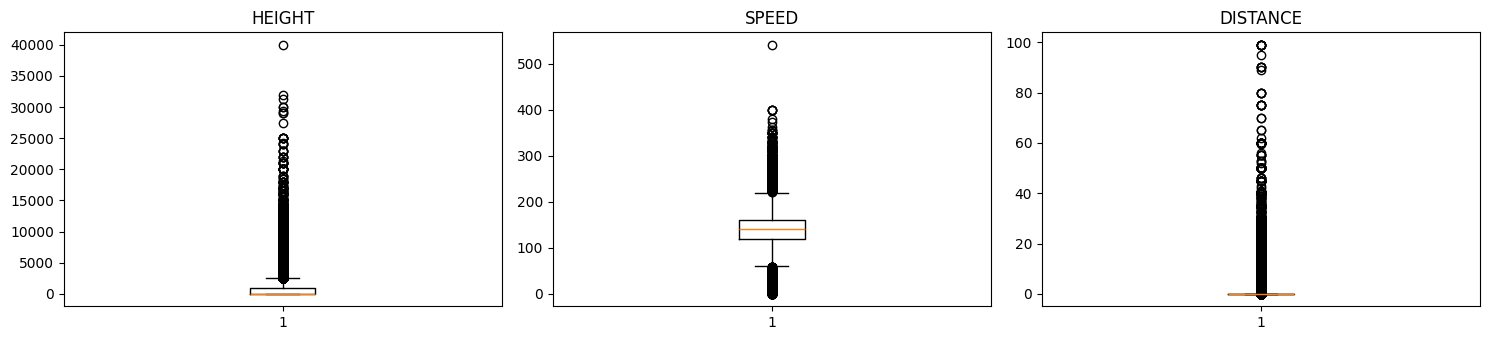

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,3, figsize=(15,3.5))

for ax,col in zip(axes,["HEIGHT","SPEED","DISTANCE"]):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col)

plt.tight_layout()

The boxplots indicate that `HEIGHT`, `SPEED`, and `DISTANCE` contain numerous extreme values, reflecting highly right-skewed distributions. 

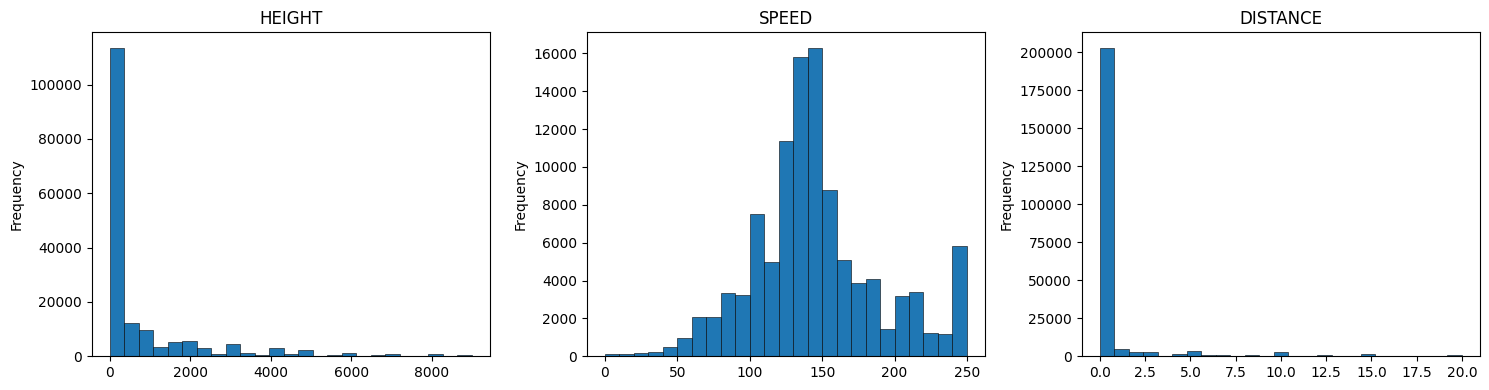

In [33]:
# Distribution to 99th percentile

numeric_cols = ["HEIGHT", "SPEED", "DISTANCE"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numeric_cols):

    upper = df[col].quantile(0.99)

    ax.hist(
        df.loc[df[col] <= upper, col].dropna(),
        bins=25,          
        edgecolor="black",
        linewidth=0.4
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

The histograms are displayed up to the 99th percentile to improve readability. Extreme observations above this threshold were retained during data cleaning.

**Conclusion**  

No negative values were identified in `HEIGHT`, `SPEED`, or `DISTANCE`. Although the distributions are strongly right-skewed with several extreme observations, these values remain operationally plausible and were therefore retained.

Missing values were not imputed because the missingness is substantial and varies across flight phases. There is insufficient evidence to accurately estimate the missing numerical values without introducing bias. Therefore, missing values were preserved and will be handled later using model-specific techniques where appropriate.

## 4.4 Data Cleaning Decisions for Flight Information Variables

| Variable(s)                 | Findings                                                                                                                                          | Treatment                                                                                                             |
| --------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------- |
| **OPID, FLT**               | Identifier variables with no analytical value for modelling.                                                                                      | No cleaning performed. Remove during feature selection.                                                               |
| **OPERATOR**                | One missing value identified.                                                                                                                     | Replace missing value with **"Unknown"**.                                                                             |
| **PHASE_OF_FLIGHT**         | Missing values present. `ENROUTE_STATE` is strongly associated with **En Route**, while numerical variables cannot reliably infer missing phases. | Recover missing values using `ENROUTE_STATE`; replace remaining missing values with **"Unknown"**.                    |
| **HEIGHT, SPEED, DISTANCE** | Right-skewed distributions with substantial missingness. No evidence of invalid values or data-entry errors.                                      | Retain all observed values, preserve valid zero values, and leave missing values (`NaN`) for model-specific handling. |


# 5. Aircraft Information Variables


## 5.1 Overview

In [34]:
aircraft_information_columns = [
    "REG",
    "AIRCRAFT",
    "AMA",
    "AMO",
    "EMA",
    "EMO",
    "AC_CLASS",
    "AC_MASS",
    "NUM_ENGS",
    "TYPE_ENG",
    "ENG_1_POS",
    "ENG_2_POS",
    "ENG_3_POS",
    "ENG_4_POS"
]

aircraft_information_overview = pd.DataFrame({
    "Variable": aircraft_information_columns,

    "Data_Type": [
        str(df[col].dtype)
        for col in aircraft_information_columns
    ],

    "Missing_Count": [
        df[col].isna().sum()
        for col in aircraft_information_columns
    ],

    "Blank_Count": [
        df[col]
        .astype("string")
        .str.strip()
        .eq("")
        .sum()
        for col in aircraft_information_columns
    ],

    "Effective_Missing_Count": [
        (
            df[col].isna()
            | df[col].astype("string").str.strip().eq("")
        ).sum()
        for col in aircraft_information_columns
    ],

    "Effective_Missing_Percent": [
        round(
            (
                df[col].isna()
                | df[col].astype("string").str.strip().eq("")
            ).mean() * 100,
            2
        )
        for col in aircraft_information_columns
    ],

    "Unique_Values": [
        df[col].nunique(dropna=False)
        for col in aircraft_information_columns
    ],

    "Example_Values": [
        df[col]
        .dropna()
        .astype(str)
        .str.strip()
        .loc[lambda x: x.ne("")]
        .drop_duplicates()
        .head(5)
        .tolist()
        for col in aircraft_information_columns
    ]
})

aircraft_information_overview

,Variable,Data_Type,Missing_Count,Blank_Count,Effective_Missing_Count,Effective_Missing_Percent,Unique_Values,Example_Values
0,REG,object,133535,0,133535,38.36,47261,"[N842AA, JA8104, N919UP, N9053U, N17413]"
1,AIRCRAFT,object,0,0,0,0.00,636,"[MERLIN IV, B-727-200, SHORTS 360, PA-31 NAVAJ..."
2,AMA,object,100101,0,100101,28.75,100,"[915, 148, 804, 729, 372]"
3,AMO,object,132945,0,132945,38.19,64,"[06, 11, 08, 25, 94]"
4,EMA,float64,115342,0,115342,33.13,39,"[19.0, 34.0, 31.0, 7.0, 37.0]"
5,EMO,float64,128511,0,128511,36.91,50,"[4.0, 10.0, 31.0, 13.0, 46.0]"
6,AC_CLASS,object,98325,0,98325,28.24,6,"[A, B, J, C, Y]"
7,AC_MASS,float64,98460,0,98460,28.28,6,"[2.0, 4.0, 3.0, 5.0, 1.0]"
8,NUM_ENGS,float64,98756,0,98756,28.37,5,"[2.0, 3.0, 4.0, 1.0]"
9,TYPE_ENG,object,98783,0,98783,28.37,8,"[C, D, A, B, F]"


- Standardize code variables.
- Treat "UNKNOWN" as missing.
- Assess REG and AIRCRAFT for missing-value recovery.
- Validate category codes.
- Investigate shared and structural missingness.

## 5.2 Category Validation

This investigation checks whether the categorical variables contain unexpected or invalid values by comparing the observed categories with the documented coding scheme.


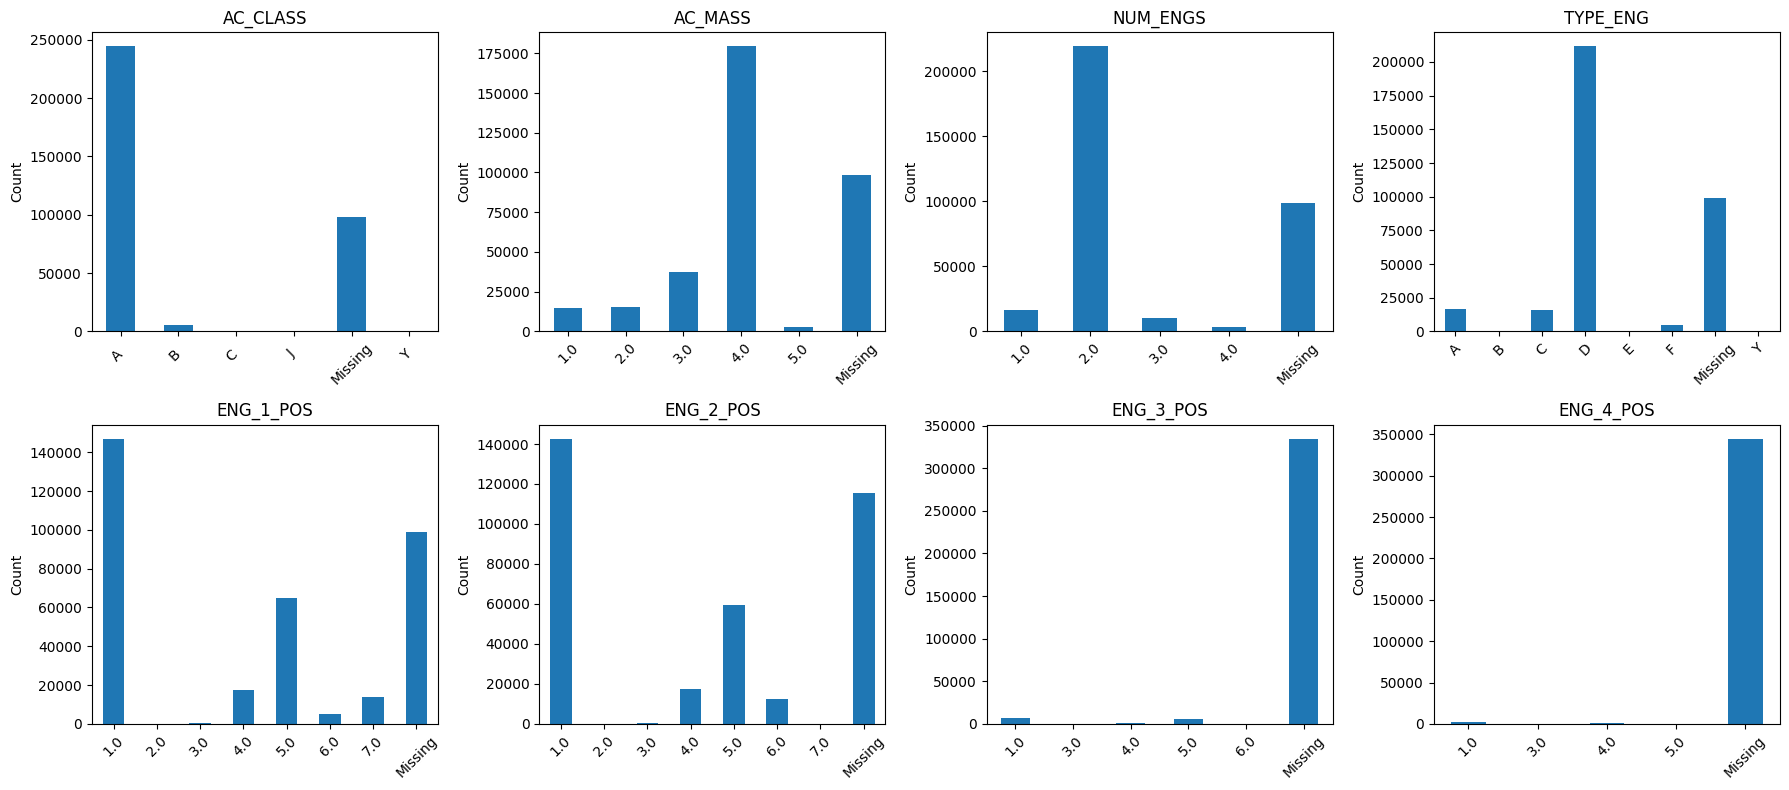

In [35]:
import matplotlib.pyplot as plt

plot_columns = [
    "AC_CLASS",
    "AC_MASS",
    "NUM_ENGS",
    "TYPE_ENG",
    "ENG_1_POS",
    "ENG_2_POS",
    "ENG_3_POS",
    "ENG_4_POS"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, col in zip(axes.flatten(), plot_columns):
    counts = (
        df[col]
        .astype("string")
        .fillna("Missing")
        .value_counts()
        .sort_index()
    )

    counts.plot(kind="bar", ax=ax)

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

All observed categories were consistent with the documented coding scheme, and no unexpected category codes were identified.

Several categories occurred very infrequently (e.g., AC_CLASS = C, J, and Y; TYPE_ENG = E and Y), but these values represent valid aircraft characteristics and were retained.

The primary data quality issue is missing information rather than invalid category values. Missing-value treatment is therefore investigated in the following sections.

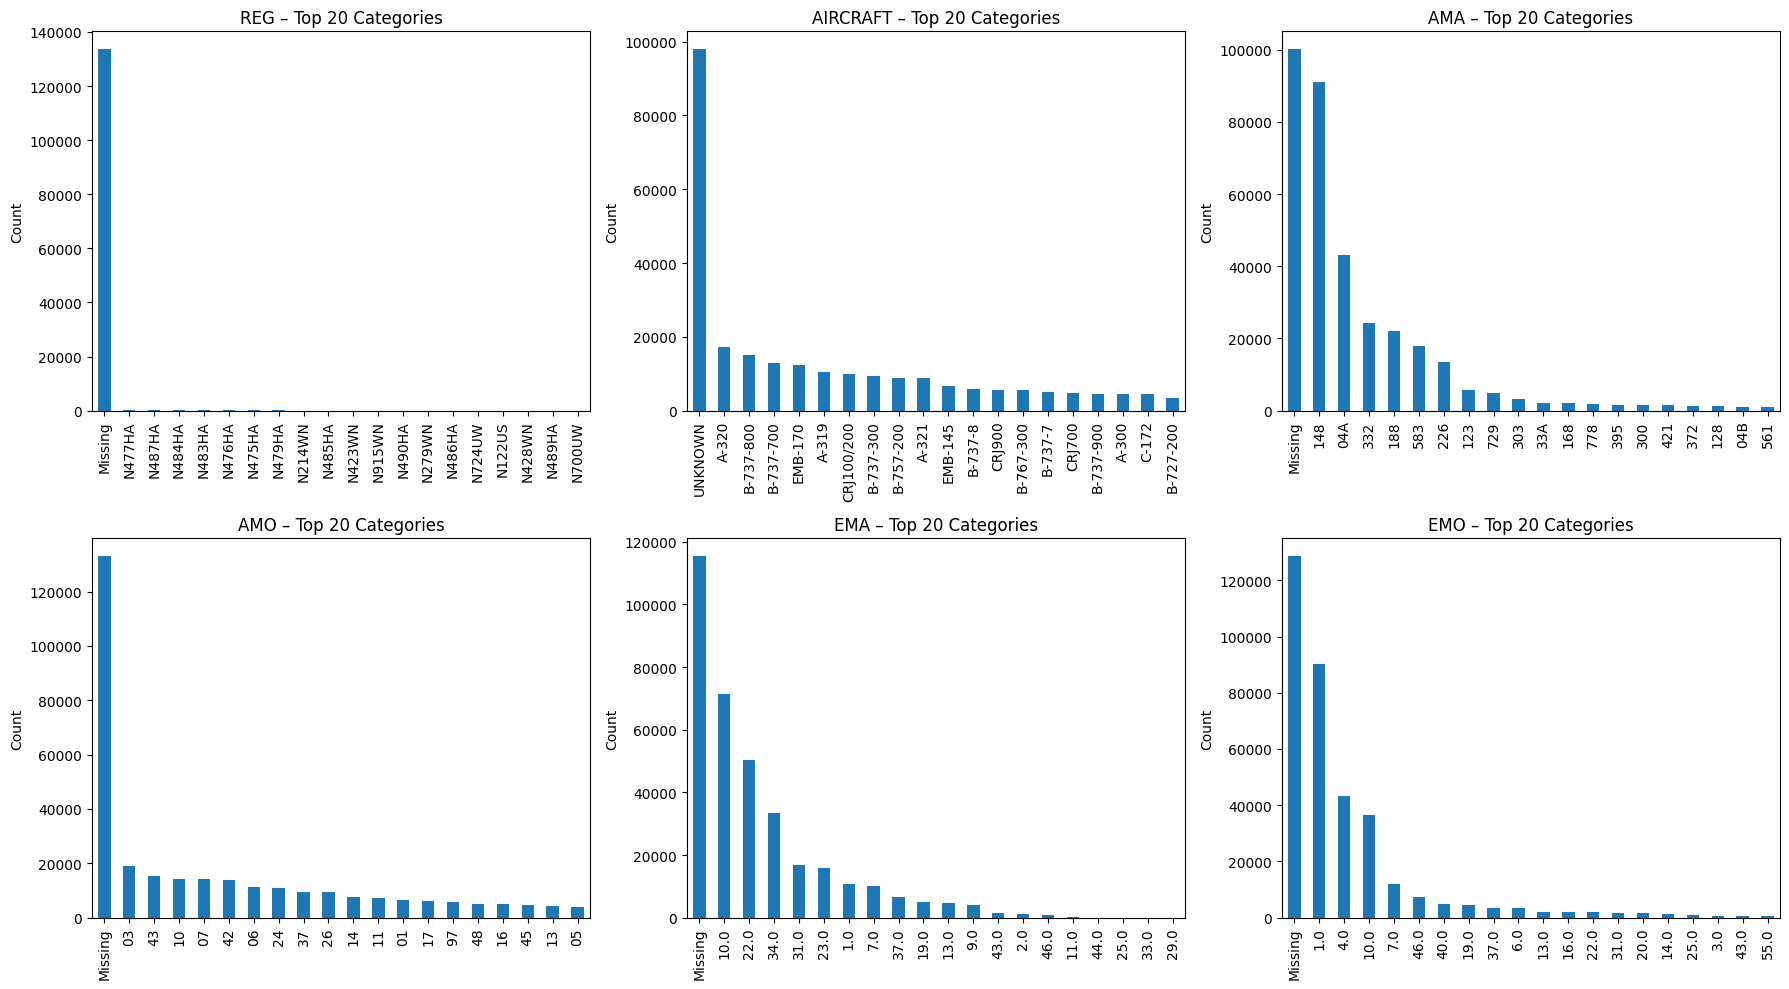

In [36]:
#Investigate REG, AIRCRAFT, AMA, AMO, EMA, EMO with large categories
import matplotlib.pyplot as plt

plot_columns = [
    "REG",
    "AIRCRAFT",
    "AMA",
    "AMO",
    "EMA",
    "EMO"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), plot_columns):
    counts = (
        df[col]
        .astype("string")
        .fillna("Missing")
        .value_counts()
        .head(20)
    )

    counts.plot(kind="bar", ax=ax)

    ax.set_title(f"{col} – Top 20 Categories")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

No obvious anomalous categories were identified from the frequency distributions. The variables are highly imbalanced and contain substantial missing information, but rare codes are not necessarily invalid. AMA, AMO, EMA, and EMO should be validated against the official lookup tables before cleaning.

## 5.3 Can REG and AIRCRAFT Support Missing-Value Recovery?

This investigation evaluates whether REG and AIRCRAFT have consistent mappings with other aircraft attributes and can therefore support missing-value recovery.

In [37]:
target_columns = [
    "AIRCRAFT",
    "AMA",
    "AMO",
    "EMA",
    "EMO",
    "AC_CLASS",
    "AC_MASS",
    "NUM_ENGS",
    "TYPE_ENG"
]

source_columns = ["REG", "AIRCRAFT"]

results = []

for source in source_columns:

    # Do not use UNKNOWN as a valid AIRCRAFT source
    source_valid = df[source].notna()

    if source == "AIRCRAFT":
        source_valid &= (
            df[source]
            .astype("string")
            .str.strip()
            .str.upper()
            .ne("UNKNOWN")
        )

    for target in target_columns:

        # Skip AIRCRAFT -> AIRCRAFT
        if source == target:
            continue

        mapping_data = df.loc[
            source_valid & df[target].notna(),
            [source, target]
        ]

        mapping_stats = (
            mapping_data
            .groupby(source)[target]
            .agg(
                Unique_Values="nunique",
                Supporting_Rows="count"
            )
        )

        # Reliable mapping:
        # one source value maps to only one target value
        reliable_sources = mapping_stats[
            mapping_stats["Unique_Values"] == 1
        ].index

        target_missing = df[target].isna()

        if target == "AIRCRAFT":
            target_missing |= (
                df[target]
                .astype("string")
                .str.strip()
                .str.upper()
                .eq("UNKNOWN")
            )

        recoverable_rows = (
            target_missing
            & source_valid
            & df[source].isin(reliable_sources)
        ).sum()

        missing_count = target_missing.sum()

        results.append({
            "Source": source,
            "Target": target,
            "Reliable_Source_Values": len(reliable_sources),
            "Missing_or_Unknown": missing_count,
            "Recoverable_Rows": recoverable_rows,
            "Recoverable_Percent": round(
                recoverable_rows / missing_count * 100, 2
            ) if missing_count > 0 else 0
        })

recovery_summary = pd.DataFrame(results)

recovery_summary

,Source,Target,Reliable_Source_Values,Missing_or_Unknown,Recoverable_Rows,Recoverable_Percent
0,REG,AIRCRAFT,44365,97884,37,0.04
1,REG,AMA,44998,100101,382,0.38
2,REG,AMO,39997,132945,8158,6.14
3,REG,EMA,43071,115342,6504,5.64
4,REG,EMO,39894,128511,8642,6.72
5,REG,AC_CLASS,46803,98325,45,0.05
6,REG,AC_MASS,46280,98460,26,0.03
7,REG,NUM_ENGS,46314,98756,27,0.03
8,REG,TYPE_ENG,46340,98783,41,0.04
9,AIRCRAFT,AMA,521,100101,1220,1.22


### Conclusion

- **AIRCRAFT -> AMO** showed the highest recovery potential (18.34%).
- **REG -> AMO, EMA, and EMO** provided moderate recovery rates (5.64% - 6.72%).
- Recovery for all other mappings was negligible.

**Missing-value handling strategy:**

- Impute **AMO** using reliable **AIRCRAFT -> AMO** mappings.
- Impute the remaining missing values in **AMO**, **EMA**, and **EMO** using reliable **REG** mappings.
- Label the remaining missing values in categorical variables as **"Unknown"**.
- Retain missing values in numerical variables as **NaN** to preserve their original data types.

## 5.4 Relationship Between NUM_ENGS and Engine Positions

In [38]:
engine_position_cols = [
    "ENG_1_POS",
    "ENG_2_POS",
    "ENG_3_POS",
    "ENG_4_POS"
]

tables = []

for col in engine_position_cols:
    temp = (
        pd.crosstab(
            df["NUM_ENGS"],
            df[col].isna()
        )
        .rename(columns={
            False: "Available",
            True: "Missing"
        })
        .reset_index()
    )

    temp.insert(1, "Engine_Position", col)

    # Ensure both columns exist
    if "Available" not in temp.columns:
        temp["Available"] = 0

    if "Missing" not in temp.columns:
        temp["Missing"] = 0

    temp["Total"] = temp["Available"] + temp["Missing"]

    temp["Available_Percent"] = (
        temp["Available"] / temp["Total"] * 100
    ).round(2)

    temp["Missing_Percent"] = (
        temp["Missing"] / temp["Total"] * 100
    ).round(2)

    tables.append(temp)

engine_position_summary = pd.concat(
    tables,
    ignore_index=True
)

engine_position_summary[
    [
        "NUM_ENGS",
        "Engine_Position",
        "Available",
        "Missing",
        "Available_Percent",
        "Missing_Percent"
    ]
]

,NUM_ENGS,Engine_Position,Available,Missing,Available_Percent,Missing_Percent
0,1.0,ENG_1_POS,16641,8,99.95,0.05
1,2.0,ENG_1_POS,219015,53,99.98,0.02
2,3.0,ENG_1_POS,10032,0,100.00,0.00
3,4.0,ENG_1_POS,3641,0,100.00,0.00
4,1.0,ENG_2_POS,0,16649,0.00,100.00
5,2.0,ENG_2_POS,218891,177,99.92,0.08
6,3.0,ENG_2_POS,10032,0,100.00,0.00
7,4.0,ENG_2_POS,3641,0,100.00,0.00
8,1.0,ENG_3_POS,0,16649,0.00,100.00
9,2.0,ENG_3_POS,0,219068,0.00,100.00


### Conclusion

- Missing values in the engine position variables were mainly structural and depended on `NUM_ENGS`.
- `ENG_2_POS`, `ENG_3_POS`, and `ENG_4_POS` were not applicable when the aircraft had fewer than two, three, or four engines, respectively.
- Therefore, structural missing values were labelled as `"Not Applicable"`.
- The small number of unexpected missing values for applicable engine positions was retained as `"Unknown"`.

## 5.5 Data Cleaning Decisions for Aircraft Information Variables


| Variable(s)                      | Findings                                                                                                                                             | Treatment                                                                                                                           |
| -------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------- |
| **AIRCRAFT, AMA, AMO, EMA, EMO** | Reliable one-to-one mappings were evaluated using **REG** and **AIRCRAFT**. Only **AMO**, **EMA**, and **EMO** showed meaningful recovery potential. | Impute **AMO** using **AIRCRAFT** first, then use **REG** to recover the remaining missing values in **AMO**, **EMA**, and **EMO**. |
| **AIRCRAFT, AMA**                | Recovery rates were negligible after mapping analysis.                                                                                               | Label remaining missing values as **"Unknown"**.                                                                                    |
| **AC_CLASS, TYPE_ENG**           | Recovery from REG and AIRCRAFT was negligible. These are categorical variables.                                                                      | Label remaining missing values as **"Unknown"**.                                                                                    |
| **AC_MASS, NUM_ENGS**            | Recovery was negligible. These variables should retain their numeric data types.                                                                     | Keep remaining missing values as **NaN**.                                                                                           |
| **ENG_1_POS – ENG_4_POS**        | Missingness depended on **NUM_ENGS** and was primarily structural rather than random.                                                                | Label structurally missing values as **"Not Applicable"**; label unexpected missing values as **"Unknown"**.                        |


## 6. Wildlife Information Variables

## 6.1 Overview

In [39]:
wildlife_information_columns = [
    "SPECIES_ID",
    "SPECIES",
    "SIZE",
    "NUM_SEEN",
    "NUM_STRUCK",
    "BIRD_BAND_NUMBER",
    "REMAINS_COLLECTED",
    "REMAINS_SENT"
]

# Keep only columns that exist in the dataset
wildlife_information_columns = [
    col for col in wildlife_information_columns
    if col in df.columns
]

wildlife_information_overview = pd.DataFrame({
    "Variable": wildlife_information_columns,

    "Data_Type": [
        str(df[col].dtype)
        for col in wildlife_information_columns
    ],

    "Missing_Count": [
        df[col].isna().sum()
        for col in wildlife_information_columns
    ],

    "Blank_Count": [
        df[col]
        .astype("string")
        .str.strip()
        .eq("")
        .sum()
        for col in wildlife_information_columns
    ],

    "Effective_Missing_Count": [
        (
            df[col].isna()
            | df[col]
                .astype("string")
                .str.strip()
                .eq("")
        ).sum()
        for col in wildlife_information_columns
    ],

    "Effective_Missing_Percent": [
        round(
            (
                df[col].isna()
                | df[col]
                    .astype("string")
                    .str.strip()
                    .eq("")
            ).mean() * 100,
            2
        )
        for col in wildlife_information_columns
    ],

    "Unique_Values": [
        df[col].nunique(dropna=False)
        for col in wildlife_information_columns
    ],

    "Example_Values": [
        (
            df[col]
            .dropna()
            .astype("string")
            .str.strip()
            .loc[lambda x: x.ne("")]
            .drop_duplicates()
            .head(5)
            .tolist()
        )
        for col in wildlife_information_columns
    ]
})

wildlife_information_overview

,Variable,Data_Type,Missing_Count,Blank_Count,Effective_Missing_Count,Effective_Missing_Percent,Unique_Values,Example_Values
0,SPECIES_ID,object,0,0,0,0.00,972,"[UNKBM, NE1, YI, UNKBS, K33]"
1,SPECIES,object,0,0,0,0.00,973,"[Unknown bird - medium, Gulls, Swallows, Unkno..."
2,SIZE,object,39365,0,39365,11.31,4,"[Medium, Small, Large]"
3,NUM_SEEN,object,236515,0,236515,67.94,5,"[2-10, More than 100, 1, 11-100]"
4,NUM_STRUCK,object,743,0,743,0.21,5,"[1, 2-10, 11-100, More than 100]"
5,BIRD_BAND_NUMBER,object,347352,0,347352,99.77,684,"[BANDED, 98737155, 183337175, 126604335, 18931..."
6,REMAINS_COLLECTED,int64,0,0,0,0.00,2,"[0, 1]"
7,REMAINS_SENT,int64,0,0,0,0.00,2,"[0, 1]"


Based on the summary above, several data quality issues require further investigation before determining the final cleaning strategy:

- `BIRD_BAND_NUMBER` has an extremely high missing rate and its analytical value should be assessed.
- The wildlife-related categorical variables should be examined for anomalies and consistency issues.
- The relationship between `SPECIES` and `SIZE` should be evaluated to determine whether missing `SIZE` values can be recovered.
- The relationship between `NUM_SEEN` and `NUM_STRUCK` should be investigated to determine whether either variable can be used for missing-value imputation.

## 6.2 Check Categorical Anomalies

In [40]:
wildlife_categorical_columns = [
    "SIZE",
    "NUM_SEEN",
    "NUM_STRUCK"
]

for col in wildlife_categorical_columns:
    print(f"\n{col}")
    print("-" * 50)

    display(
        df[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="Count")
    )


SIZE
--------------------------------------------------


,SIZE,Count
0,Small,214313
1,Medium,73623
2,NaN,39365
3,Large,20845



NUM_SEEN
--------------------------------------------------


,NUM_SEEN,Count
0,NaN,236515
1,1,68422
2,2-10,33984
3,11-100,8132
4,More than 100,1093



NUM_STRUCK
--------------------------------------------------


,NUM_STRUCK,Count
0,1,309989
1,2-10,35688
2,11-100,1667
3,NaN,743
4,More than 100,59


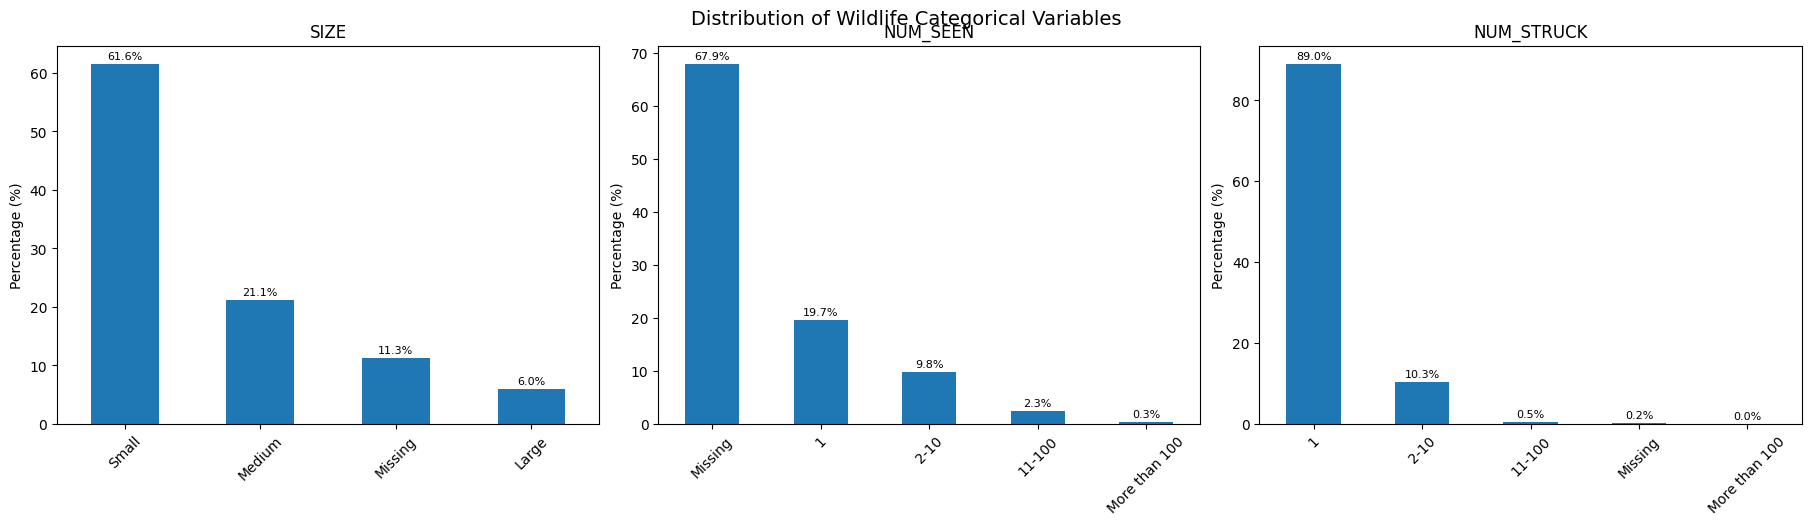

In [41]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5),
    constrained_layout=True
)

for ax, col in zip(axes, wildlife_categorical_columns):

    percentages = (
        df[col]
        .fillna("Missing")
        .value_counts(normalize=True)
        .mul(100)
    )

    percentages.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Percentage (%)")
    ax.tick_params(axis="x", rotation=45)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            fontsize=8,
            padding=2
        )

plt.suptitle(
    "Distribution of Wildlife Categorical Variables",
    fontsize=14,
    y=1.02
)

plt.show()

- `NUM_SEEN`: Correct the inconsistent category `"1.0"` to `"1"`

## 6.3 Can `SPECIES` Be Used to Impute Missing Values in `SIZE`?

In [42]:
# Check each Species corresponding to 1 Size only?
species_size = (
    df[
        ["SPECIES", "SIZE"]
    ]
    .dropna()
    .groupby("SPECIES")["SIZE"]
    .nunique()
    .value_counts()
    .sort_index()
)

species_size

SIZE
1    967
Name: count, dtype: int64

Species is a reliable predictor of Size.

## 6.4 Can `NUM_STRUCK` Be Used to Impute Missing Values in `NUM_SEEN`?

In [43]:
cross = pd.crosstab(
    df["NUM_SEEN"],
    df["NUM_STRUCK"]
)

cross

NUM_STRUCK,1,11-100,2-10,More than 100
NUM_SEEN,,,,
1,66917,28,1110,1
11-100,3506,883,3667,2
2-10,20610,68,13048,2
More than 100,371,207,437,40


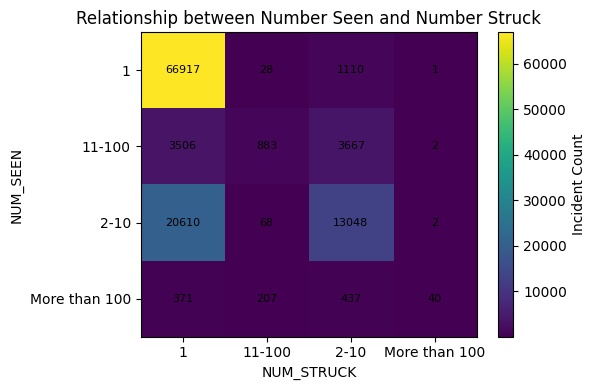

In [44]:
cross = pd.crosstab(
    df["NUM_SEEN"],
    df["NUM_STRUCK"]
)

plt.figure(figsize=(6,4))

plt.imshow(cross, aspect="auto")

plt.xticks(
    range(len(cross.columns)),
    cross.columns
)

plt.yticks(
    range(len(cross.index)),
    cross.index
)

plt.xlabel("NUM_STRUCK")
plt.ylabel("NUM_SEEN")
plt.title("Relationship between Number Seen and Number Struck")

for i in range(cross.shape[0]):
    for j in range(cross.shape[1]):
        plt.text(
            j,
            i,
            cross.iloc[i, j],
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(label="Incident Count")
plt.tight_layout()
plt.show()

Although `NUM_SEEN` and `NUM_STRUCK` were associated, their relationship was
not deterministic. Therefore, `NUM_SEEN` was not used to impute missing values
in `NUM_STRUCK`. The remaining missing values in `NUM_STRUCK` will be retained as
`NaN` because the missing rate was very low and no reliable imputation rule
was identified.

## 6.5 Data Cleaning Decisions For Wildlife Information Variables

| Variables          | Findings                                                                                                                                                       | Treatment                                                                                                           |
| ------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------- |
| `SPECIES`, `SIZE`  | A reliable `SPECIES → SIZE` mapping was identified for recovering missing `SIZE` values.                                                                       | Impute missing `SIZE` values using the `SPECIES → SIZE` mapping. Label any remaining missing values as `"Unknown"`. |
| `NUM_SEEN`         | The category `"1.0"` was an inconsistent representation of `"1"`. No deterministic relationship with `NUM_STRUCK` was identified for missing-value imputation. | Standardize `"1.0"` to `"1"` and retain the remaining missing values as `NaN`.                                      |
| `NUM_STRUCK`       | No deterministic relationship with `NUM_SEEN` was identified for missing-value imputation.                                                                     | Retain the remaining missing values as `NaN`.                                                                       |
| `BIRD_BAND_NUMBER` | More than 99% of the values were missing, providing limited analytical value.                                                                                  | Remove the variable from the dataset.                                                                               |


## 7. Other Conditions Information Variables

In [45]:
wildlife_information_columns = [
    "SKY", "PRECIPITATION", "WARNED"
]

# Keep only columns that exist in the dataset
wildlife_information_columns = [
    col for col in wildlife_information_columns
    if col in df.columns
]

wildlife_information_overview = pd.DataFrame({
    "Variable": wildlife_information_columns,

    "Data_Type": [
        str(df[col].dtype)
        for col in wildlife_information_columns
    ],

    "Missing_Count": [
        df[col].isna().sum()
        for col in wildlife_information_columns
    ],

    "Blank_Count": [
        df[col]
        .astype("string")
        .str.strip()
        .eq("")
        .sum()
        for col in wildlife_information_columns
    ],

    "Effective_Missing_Count": [
        (
            df[col].isna()
            | df[col]
                .astype("string")
                .str.strip()
                .eq("")
        ).sum()
        for col in wildlife_information_columns
    ],

    "Effective_Missing_Percent": [
        round(
            (
                df[col].isna()
                | df[col]
                    .astype("string")
                    .str.strip()
                    .eq("")
            ).mean() * 100,
            2
        )
        for col in wildlife_information_columns
    ],

    "Unique_Values": [
        df[col].nunique(dropna=False)
        for col in wildlife_information_columns
    ],

    "Example_Values": [
        (
            df[col]
            .dropna()
            .astype("string")
            .str.strip()
            .loc[lambda x: x.ne("")]
            .drop_duplicates()
            .head(5)
            .tolist()
        )
        for col in wildlife_information_columns
    ]
})

wildlife_information_overview

,Variable,Data_Type,Missing_Count,Blank_Count,Effective_Missing_Count,Effective_Missing_Percent,Unique_Values,Example_Values
0,SKY,object,184974,0,184974,53.13,4,"[No Cloud, Overcast, Some Cloud]"
1,PRECIPITATION,object,335510,0,335510,96.37,11,"[Fog, Rain, Snow, Fog, Rain, Rain, Snow]"
2,WARNED,object,0,0,0,0.00,3,"[Unknown, No, Yes]"


The variables should be examined for anomalies and handling missing values

In [46]:
# Check Missing values and anomalies

for col in ["SKY", "PRECIPITATION", "WARNED"]:
    print(f"\n{col}")
    display(
        df[col]
        .fillna("Missing")
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="Count")
    )


SKY


,SKY,Count
0,Missing,184974
1,No Cloud,79894
2,Some Cloud,56100
3,Overcast,27178



PRECIPITATION


,PRECIPITATION,Count
0,Missing,335510
1,Rain,8798
2,Fog,2749
3,Snow,637
4,"Fog, Rain",358
5,"Rain, Snow",31
6,"Fog, Snow",20
7,"None, Snow",18
8,"None, Rain",13
9,"Fog, Rain, Snow",6



WARNED


,WARNED,Count
0,Unknown,216877
1,No,67507
2,Yes,63762


`SKY` contained three consistent categories, but more than half of its values
were missing. No reliable imputation strategy was identified, so the missing
values were retained as `NaN`.

`PRECIPITATION` had an extremely high missing rate. Inconsistent combinations
containing `None` alongside observed weather conditions were standardized by
removing `None`. The remaining missing values were retained as `NaN`.

WARNED consisted of three valid categories (Yes, No, and Unknown). As Unknown represents an explicit status rather than a missing value, the variable was retained without further modification.

| Variables       | Findings                                                                                   | Treatment                                                                               |
| --------------- | ------------------------------------------------------------------------------------------ | --------------------------------------------------------------------------------------- |
| `SKY`           | Three consistent categories with 53.13% missing values.                                    | Retain valid categories and keep missing values as `NaN`.                               |
| `PRECIPITATION` | Extremely high missing rate (96.37%) with a few inconsistent categories containing `None`. | Standardize inconsistent categories by removing `None`; retain missing values as `NaN`. |
| `WARNED`        | Three valid categories (`Yes`, `No`, `Unknown`); `Unknown` is a valid status.              | Retain the original categories without modification.                                    |


## 8. Target Variables

In [47]:
wildlife_information_columns = [
    "INDICATED_DAMAGE",
"DAMAGE_LEVEL"

]

# Keep only columns that exist in the dataset
wildlife_information_columns = [
    col for col in wildlife_information_columns
    if col in df.columns
]

wildlife_information_overview = pd.DataFrame({
    "Variable": wildlife_information_columns,

    "Data_Type": [
        str(df[col].dtype)
        for col in wildlife_information_columns
    ],

    "Missing_Count": [
        df[col].isna().sum()
        for col in wildlife_information_columns
    ],

    "Blank_Count": [
        df[col]
        .astype("string")
        .str.strip()
        .eq("")
        .sum()
        for col in wildlife_information_columns
    ],

    "Effective_Missing_Count": [
        (
            df[col].isna()
            | df[col]
                .astype("string")
                .str.strip()
                .eq("")
        ).sum()
        for col in wildlife_information_columns
    ],

    "Effective_Missing_Percent": [
        round(
            (
                df[col].isna()
                | df[col]
                    .astype("string")
                    .str.strip()
                    .eq("")
            ).mean() * 100,
            2
        )
        for col in wildlife_information_columns
    ],

    "Unique_Values": [
        df[col].nunique(dropna=False)
        for col in wildlife_information_columns
    ],

    "Example_Values": [
        (
            df[col]
            .dropna()
            .astype("string")
            .str.strip()
            .loc[lambda x: x.ne("")]
            .drop_duplicates()
            .head(5)
            .tolist()
        )
        for col in wildlife_information_columns
    ]
})

wildlife_information_overview

,Variable,Data_Type,Missing_Count,Blank_Count,Effective_Missing_Count,Effective_Missing_Percent,Unique_Values,Example_Values
0,INDICATED_DAMAGE,int64,0,0,0,0.00,2,"[0, 1]"
1,DAMAGE_LEVEL,object,122605,0,122605,35.22,6,"[N, M, S, M?, D]"


INDICATED_DAMAGE is a clean binary target with no missing values. No preprocessing was required. 

In [48]:
pd.crosstab(
    df["INDICATED_DAMAGE"],
    df["DAMAGE_LEVEL"].fillna("Missing"),
    margins=True
)

DAMAGE_LEVEL,D,M,M?,Missing,N,S,All
INDICATED_DAMAGE,,,,,,,
0,0,0,2,122605,203493,0,326100
1,89,8783,8770,0,3,4401,22046
All,89,8783,8772,122605,203496,4401,348146


- Missing of DAMAGE_LEVEL when INDICATED_DAMAGE = 0 suggests that the level of Damage was not filled because there was no damage. 

- There are 5 cases of inconsistency should be examined:

        INDICATED_DAMAGE = 0 and  DAMAGE_LEVEL = M?: 2 records

        INDICATED_DAMAGE = 1 and DAMAGE_LEVEL = N: 3 records

In [49]:
inconsistent_damage = df[
    (
        (df["INDICATED_DAMAGE"] == 0) &
        (df["DAMAGE_LEVEL"].isin(["M", "M?", "S", "D"]))
    )
    |
    (
        (df["INDICATED_DAMAGE"] == 1) &
        (df["DAMAGE_LEVEL"] == "N")
    )
]

display(inconsistent_damage)

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,...,NR_INJURIES,NR_FATALITIES,COMMENTS,IMAGE,REPORTED_NAME,REPORTED_TITLE,SOURCE,PERSON,LUPDATE,TRANSFER
344421,1850403,26/2/2026 00:00:00,2,2026,,NaN,ZZZZ,UNKNOWN,NaN,NaN,...,NaN,NaN,NaN,1,REDACTED,REDACTED,FAA Form 5200-7-E,Airport Operations,29/5/2026 00:00:00,0
344647,1851211,4/3/2026 00:00:00,3,2026,,NaN,ZZZZ,UNKNOWN,NaN,NaN,...,NaN,NaN,NaN,0,REDACTED,REDACTED,MOR,Tower,2/6/2026 00:00:00,0
346517,1857330,11/4/2026 00:00:00,4,2026,08:10,Day,KSFO,SAN FRANCISCO INTL ARPT,NaN,NaN,...,NaN,NaN,*** Strike Report: 2026-04-11-121518-R1( Repor...,0,REDACTED,REDACTED,Multiple,Airport Operations,22/6/2026 00:00:00,0
347236,1859343,23/4/2026 00:00:00,4,2026,15:45,Day,06A,MOTON FIELD MUNICIPAL AIRPORT,NaN,NaN,...,NaN,NaN,NaN,1,REDACTED,REDACTED,FAA Form 5200-7-E,Pilot,29/6/2026 00:00:00,0
347543,1860040,26/4/2026 00:00:00,4,2026,16:43,Day,KSDF,MUHAMMAD ALI INTERNATIONAL,NaN,NaN,...,NaN,NaN,NaN,0,REDACTED,REDACTED,FAA Form 5200-7-E,Air Transport Operations,30/6/2026 00:00:00,0


In [50]:
review_columns = [
    "INDICATED_DAMAGE",
    "DAMAGE_LEVEL",
    "STR_ENG1",
    "DAM_ENG1",
    "STR_ENG2",
    "DAM_ENG2",
    "STR_ENG3",
    "DAM_ENG3",
    "STR_ENG4",
    "DAM_ENG4",
    "STR_PROP",
    "DAM_PROP",
    "STR_WING_ROT",
    "DAM_WING_ROT",
    "STR_FUSE",
    "DAM_FUSE",
    "STR_LG",
    "DAM_LG",
    "STR_TAIL",
    "DAM_TAIL",
    "STR_LGHTS",
    "DAM_LGHTS",
    "STR_OTHER",
    "DAM_OTHER",
    "OTHER_SPECIFY",
    "EFFECT",
    "EFFECT_OTHER",
    "NUM_STRUCK",
    "STR_RAD",
    "DAM_RAD"
]



review_columns = [
    col for col in review_columns
    if col in df.columns
]

display(inconsistent_damage[review_columns])

,INDICATED_DAMAGE,DAMAGE_LEVEL,STR_ENG1,DAM_ENG1,STR_ENG2,DAM_ENG2,STR_ENG3,DAM_ENG3,STR_ENG4,DAM_ENG4,...,STR_LGHTS,DAM_LGHTS,STR_OTHER,DAM_OTHER,OTHER_SPECIFY,EFFECT,EFFECT_OTHER,NUM_STRUCK,STR_RAD,DAM_RAD
344421,1,N,1,1,0,0,0,0,0,0,...,0,0,0,0,NaN,NaN,NaN,1,0,0
344647,0,M?,0,0,0,0,0,0,0,0,...,0,0,1,0,PART NOT REPORTED,NaN,NaN,1,0,0
346517,1,N,0,0,0,0,0,0,0,0,...,0,0,0,0,NaN,NaN,NaN,2-10,0,0
347236,0,M?,0,0,0,0,0,0,0,0,...,0,0,0,0,NaN,NaN,NaN,1,0,0
347543,1,N,0,0,0,0,0,0,0,0,...,0,0,0,0,NaN,NaN,NaN,1,0,0


**Cleaning Decisions:**

- Record 344421: INDICATED_DAMAGE = 1 was supported by DAM_ENG1 = 1, confirming engine damage. Therefore, INDICATED_DAMAGE was retained, while DAMAGE_LEVEL was changed from N to M? because the exact severity could not be determined.
- Record 344647: DAMAGE_LEVEL = M? indicates that damage occurred, although the severity was undetermined. Therefore, INDICATED_DAMAGE was changed from 0 to 1.
Record 346517: INDICATED_DAMAGE = 1 conflicted with DAMAGE_LEVEL = N, and no component-level damage or other supporting evidence was available. Because the correct target value could not be determined reliably, the record was removed.
- Record 347236: DAMAGE_LEVEL = M? confirms that damage occurred but its severity was unknown. Therefore, INDICATED_DAMAGE was changed from 0 to 1.
- Record 347543: INDICATED_DAMAGE = 1 conflicted with DAMAGE_LEVEL = N, while no supporting damage information was available. The record was removed because the correct target value could not be determined reliably.

| Variables          | Findings                                                                     | Treatment                                                                                                              |
| ------------------ | ---------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------- |
| `INDICATED_DAMAGE` | Clean binary primary target.                                                 | Retain original values.                                                                                                |
| `DAMAGE_LEVEL`     | Valid severity categories with missing values and five inconsistent records. | Fill missing values based on `INDICATED_DAMAGE`; retain `M?`; correct three records and remove two unresolved records. |


# 9. Aircraft Components Struck and Damaged Variables

In [51]:
component_information_columns = [
    "STR_RAD",
    "DAM_RAD",
    "STR_WINDSHLD",
    "DAM_WINDSHLD",
    "STR_NOSE",
    "DAM_NOSE",
    "STR_ENG1",
    "DAM_ENG1",
    "STR_ENG2",
    "DAM_ENG2",
    "STR_ENG3",
    "DAM_ENG3",
    "STR_ENG4",
    "DAM_ENG4",
    "STR_PROP",
    "DAM_PROP",
    "STR_WING_ROT",
    "DAM_WING_ROT",
    "STR_FUSE",
    "DAM_FUSE",
    "STR_LG",
    "DAM_LG",
    "STR_TAIL",
    "DAM_TAIL",
    "STR_LGHTS",
    "DAM_LGHTS",
    "STR_OTHER",
    "DAM_OTHER",
    "INGESTED_OTHER",
    "OTHER_SPECIFY",
    
]

# Keep only columns that exist in the dataset
component_information_columns = [
    col for col in component_information_columns
    if col in df.columns
]

component_information_overview = pd.DataFrame({
    "Variable": component_information_columns,

    "Data_Type": [
        str(df[col].dtype)
        for col in component_information_columns
    ],

    "Missing_Count": [
        df[col].isna().sum()
        for col in component_information_columns
    ],

    "Blank_Count": [
        df[col]
        .astype("string")
        .str.strip()
        .eq("")
        .sum()
        for col in component_information_columns
    ],

    "Effective_Missing_Count": [
        (
            df[col].isna()
            | df[col]
                .astype("string")
                .str.strip()
                .eq("")
        ).sum()
        for col in component_information_columns
    ],

    "Effective_Missing_Percent": [
        round(
            (
                df[col].isna()
                | df[col]
                    .astype("string")
                    .str.strip()
                    .eq("")
            ).mean() * 100,
            2
        )
        for col in component_information_columns
    ],

    "Unique_Values": [
        df[col].nunique(dropna=False)
        for col in component_information_columns
    ],

    "Example_Values": [
        (
            df[col]
            .dropna()
            .astype("string")
            .str.strip()
            .loc[lambda x: x.ne("")]
            .drop_duplicates()
            .head(5)
            .tolist()
        )
        for col in component_information_columns
    ]
})

component_information_overview

,Variable,Data_Type,Missing_Count,Blank_Count,Effective_Missing_Count,Effective_Missing_Percent,Unique_Values,Example_Values
0,STR_RAD,int64,0,0,0,0.00,2,"[1, 0]"
1,DAM_RAD,int64,0,0,0,0.00,2,"[0, 1]"
2,STR_WINDSHLD,int64,0,0,0,0.00,2,"[1, 0]"
3,DAM_WINDSHLD,int64,0,0,0,0.00,2,"[0, 1]"
4,STR_NOSE,int64,0,0,0,0.00,2,"[0, 1]"
5,DAM_NOSE,int64,0,0,0,0.00,2,"[0, 1]"
6,STR_ENG1,int64,0,0,0,0.00,2,"[0, 1]"
7,DAM_ENG1,int64,0,0,0,0.00,2,"[0, 1]"
8,STR_ENG2,int64,0,0,0,0.00,2,"[0, 1]"
9,DAM_ENG2,int64,0,0,0,0.00,2,"[0, 1]"


All component strike (STR_*) and damage (DAM_*) variables were binary indicators with no missing values or invalid categories.
OTHER_SPECIFY contains free-text descriptions of aircraft components not covered by the predefined strike categories. The variable is highly sparse (85.97% missing) and contains 3,333 unique descriptions, reflecting substantial variability in reporting.

In [52]:
# Examining Logical consistency between STR and DAM
component_pairs = [
    ("STR_RAD", "DAM_RAD"),
    ("STR_WINDSHLD", "DAM_WINDSHLD"),
    ("STR_NOSE", "DAM_NOSE"),
    ("STR_ENG1", "DAM_ENG1"),
    ("STR_ENG2", "DAM_ENG2"),
    ("STR_ENG3", "DAM_ENG3"),
    ("STR_ENG4", "DAM_ENG4"),
    ("STR_PROP", "DAM_PROP"),
    ("STR_WING_ROT", "DAM_WING_ROT"),
    ("STR_FUSE", "DAM_FUSE"),
    ("STR_LG", "DAM_LG"),
    ("STR_TAIL", "DAM_TAIL"),
    ("STR_LGHTS", "DAM_LGHTS"),
    ("STR_OTHER", "DAM_OTHER")
]

results = []

for struck, damaged in component_pairs:

    inconsistent = (
        (df[struck] == 0) &
        (df[damaged] == 1)
    ).sum()

    results.append({
        "Component": struck.replace("STR_", ""),
        "Inconsistent_Records": inconsistent
    })

pd.DataFrame(results)

,Component,Inconsistent_Records
0,RAD,14
1,WINDSHLD,27
2,NOSE,51
3,ENG1,62
4,ENG2,33
5,ENG3,5
6,ENG4,4
7,PROP,80
8,WING_ROT,130
9,FUSE,100


In [53]:
inconsistent_masks = []

for struck, damaged in component_pairs:
    inconsistent_masks.append(
        (df[struck] == 0) & (df[damaged] == 1)
    )

any_component_inconsistency = pd.concat(
    inconsistent_masks,
    axis=1
).any(axis=1)

print(
    "Unique inconsistent records:",
    any_component_inconsistency.sum()
)

Unique inconsistent records: 401


A consistency check identified 401 records (0.12% of the dataset) where a component was recorded as damaged (DAM_* = 1) but not struck (STR_* = 0). However, based on the FAA variable definitions, the strike and damage indicators represent separate event characteristics, and the data dictionary does not require the damaged component to be the same component recorded as struck. Therefore, these records were retained without modification.

| Variables                               | Findings                                                                                                                                                                                                                                              | Treatment                                                                                                                                         |
| --------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------- |
| `STR_*`                                 | Binary indicators identifying aircraft components reported as struck; no missing or invalid values.                                                                                                                                                   | Retain original values.                                                                                                                           |
| `DAM_*`                                 | Binary indicators identifying aircraft components reported as damaged; no missing or invalid values. A total of 401 records contained at least one `DAM_* = 1` with the paired `STR_* = 0`.                                                           | Retain original values because the struck component and the damaged component are not necessarily the same according to the FAA data definitions. |
| `ING_ENG1`–`ING_ENG4`, `INGESTED_OTHER` | Complete binary indicators describing wildlife ingestion into aircraft engines or other locations, with no missing or invalid values.                                                                                                                 | Retain original values.                                                                                                                           |
| `OTHER_SPECIFY`                         | Free-text descriptions for aircraft components not covered by the predefined categories. The variable contained **85.97%** missing values and **3,333** unique descriptions, indicating high reporting variability and a high-cardinality text field. | Retain the original text for reference only. No text standardization was performed, and the variable was excluded from structured modelling.      |


# 10. Flight Consequences and Human Impact

In [54]:
consequence_columns = [
    "EFFECT",
    "EFFECT_OTHER",
    "AOS",
    "NR_INJURIES",
    "NR_FATALITIES"
]

# Keep only variables available in the dataset
consequence_columns = [
    col for col in consequence_columns
    if col in df.columns
]

consequence_overview = pd.DataFrame({
    "Variable": consequence_columns,

    "Data_Type": [
        str(df[col].dtype)
        for col in consequence_columns
    ],

    "Missing_Count": [
        df[col].isna().sum()
        for col in consequence_columns
    ],

    "Blank_Count": [
        df[col]
        .astype("string")
        .str.strip()
        .eq("")
        .sum()
        for col in consequence_columns
    ],

    "Effective_Missing_Count": [
        (
            df[col].isna()
            |
            df[col]
            .astype("string")
            .str.strip()
            .eq("")
        ).sum()
        for col in consequence_columns
    ],

    "Effective_Missing_Percent": [
        round(
            (
                df[col].isna()
                |
                df[col]
                .astype("string")
                .str.strip()
                .eq("")
            ).mean() * 100,
            2
        )
        for col in consequence_columns
    ],

    "Unique_Values": [
        df[col].nunique(dropna=False)
        for col in consequence_columns
    ],

    "Example_Values": [
        (
            df[col]
            .dropna()
            .astype("string")
            .str.strip()
            .loc[lambda x: x.ne("")]
            .drop_duplicates()
            .head(5)
            .tolist()
        )
        for col in consequence_columns
    ]
})

consequence_overview

,Variable,Data_Type,Missing_Count,Blank_Count,Effective_Missing_Count,Effective_Missing_Percent,Unique_Values,Example_Values
0,EFFECT,object,332211,0,332211,95.42,13,"[Precautionary Landing, Aborted Take-off, Othe..."
1,EFFECT_OTHER,object,345363,0,345363,99.20,831,"[AVOIDANCE MANEUVER, FLEW BY TWR TO CHECK GEAR..."
2,AOS,float64,330712,0,330712,94.99,512,"[3.0, 1.0, 14.0, 2.0, 1344.0]"
3,NR_INJURIES,float64,347844,0,347844,99.91,7,"[1.0, 2.0, 5.0, 7.0, 4.0]"
4,NR_FATALITIES,float64,348121,0,348121,99.99,7,"[1.0, 2.0, 8.0, 3.0, 5.0]"


The flight consequence and human impact variables contain very high levels of missing data, ranging from 94.99% to 99.99%. EFFECT is a categorical variable with 13 distinct values, while EFFECT_OTHER contains highly varied free-text descriptions. AOS, NR_INJURIES, and NR_FATALITIES are numeric variables, but only a small proportion of records contain reported values.

| Variables                      | Treatment                                                                                                  |
| ------------------------------ | ---------------------------------------------------------------------------------------------------------- |
| `EFFECT`                       | Retain original categories; fill missing values with `Unknown` only if required for descriptive summaries. |
| `EFFECT_OTHER`                 | Retain as free text; do not use directly in modelling.                                                     |
| `AOS`                          | Retain numeric values and missing values; no imputation.                                                   |
| `NR_INJURIES`, `NR_FATALITIES` | Retain original values; do not impute or use as predictors.                                                |


# 11. Cost Variables

In [55]:
cost_information_columns = [
    
    "COST_REPAIRS",
    "COST_OTHER",
    "COST_REPAIRS_INFL_ADJ",
    "COST_OTHER_INFL_ADJ"
]

cost_information_columns = [
    col for col in cost_information_columns
    if col in df.columns
]

cost_information_overview = pd.DataFrame({
    "Variable": cost_information_columns,

    "Data_Type": [
        str(df[col].dtype)
        for col in cost_information_columns
    ],

    "Missing_Count": [
        df[col].isna().sum()
        for col in cost_information_columns
    ],

    "Blank_Count": [
        df[col]
        .astype("string")
        .str.strip()
        .eq("")
        .sum()
        for col in cost_information_columns
    ],

    "Effective_Missing_Count": [
        (
            df[col].isna()
            |
            df[col]
            .astype("string")
            .str.strip()
            .eq("")
        ).sum()
        for col in cost_information_columns
    ],

    "Effective_Missing_Percent": [
        round(
            (
                df[col].isna()
                |
                df[col]
                .astype("string")
                .str.strip()
                .eq("")
            ).mean()*100,
            2
        )
        for col in cost_information_columns
    ],

    "Unique_Values": [
        df[col].nunique(dropna=False)
        for col in cost_information_columns
    ],

    "Example_Values": [
        (
            df[col]
            .dropna()
            .astype("string")
            .str.strip()
            .loc[lambda x: x.ne("")]
            .drop_duplicates()
            .head(5)
            .tolist()
        )
        for col in cost_information_columns
    ]
})

cost_information_overview

,Variable,Data_Type,Missing_Count,Blank_Count,Effective_Missing_Count,Effective_Missing_Percent,Unique_Values,Example_Values
0,COST_REPAIRS,object,342721,0,342721,98.44,1368,"[$2200.00, $2500.00, $45000.00, $5000.00, $400..."
1,COST_OTHER,object,342584,0,342584,98.40,692,"[$15000.00, $2000.00, $66.00, $5000.00, $200.00]"
2,COST_REPAIRS_INFL_ADJ,object,342721,0,342721,98.44,3145,"[$5412.00, $5730.00, $100125.00, $12300.00, $5..."
3,COST_OTHER_INFL_ADJ,object,342584,0,342584,98.40,1806,"[$36900.00, $4722.00, $151.00, $12300.00, $492..."


With a missing rate exceeding 98%, the cost group is unsuitable for impute or use as the primary forecast variable. However, it is still advisable to verify the format and validity of approximately 5,500 records containing data.

In [56]:
#Temporarily convert to numeric for testing
cost_numeric_columns = []

for col in cost_information_columns:
    numeric_col = f"{col}_NUMERIC"

    df[numeric_col] = pd.to_numeric(
        df[col]
        .astype("string")
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

    cost_numeric_columns.append(numeric_col)

In [57]:
# Check if there are any unparsable values
conversion_summary = pd.DataFrame({
    "Variable": cost_information_columns,
    "Original_Non_Missing": [
        df[col].notna().sum()
        for col in cost_information_columns
    ],
    "Converted_Non_Missing": [
        df[f"{col}_NUMERIC"].notna().sum()
        for col in cost_information_columns
    ],
    "Conversion_Failures": [
        (
            df[col].notna()
            & df[f"{col}_NUMERIC"].isna()
        ).sum()
        for col in cost_information_columns
    ]
})

conversion_summary

,Variable,Original_Non_Missing,Converted_Non_Missing,Conversion_Failures
0,COST_REPAIRS,5425,5425,0
1,COST_OTHER,5562,5562,0
2,COST_REPAIRS_INFL_ADJ,5425,5425,0
3,COST_OTHER_INFL_ADJ,5562,5562,0


Conversion_Failures = 0, the currency format has been converted cleanly.

In [58]:
# Zero, negative, and distribution testing

cost_value_summary = pd.DataFrame({
    "Variable": cost_numeric_columns,

    "Missing_Count": [
        df[col].isna().sum()
        for col in cost_numeric_columns
    ],

    "Zero_Count": [
        df[col].eq(0).sum()
        for col in cost_numeric_columns
    ],

    "Negative_Count": [
        df[col].lt(0).sum()
        for col in cost_numeric_columns
    ],

    "Positive_Count": [
        df[col].gt(0).sum()
        for col in cost_numeric_columns
    ],

    "Minimum": [
        df[col].min()
        for col in cost_numeric_columns
    ],

    "Median": [
        df[col].median()
        for col in cost_numeric_columns
    ],

    "Maximum": [
        df[col].max()
        for col in cost_numeric_columns
    ]
})

cost_value_summary

,Variable,Missing_Count,Zero_Count,Negative_Count,Positive_Count,Minimum,Median,Maximum
0,COST_REPAIRS_NUMERIC,342721,0,0,5425,2.0,12000.0,50000000.0
1,COST_OTHER_NUMERIC,342584,0,0,5562,1.0,513.5,12500000.0
2,COST_REPAIRS_INFL_ADJ_NUMERIC,342721,0,0,5425,2.0,18521.0,53928000.0
3,COST_OTHER_INFL_ADJ_NUMERIC,342584,0,0,5562,1.0,725.0,13737500.0


The four cost variables contained extremely high levels of missing data (approximately 98.4%), indicating that cost reporting was optional rather than mandatory. Among the available records, all values were successfully converted to numeric format, with no negative values observed. The cost distributions were highly right-skewed, ranging from very small amounts (USD 1–2) to tens of millions of dollars.

In [59]:
# Check consistency between original and inflation-adjusted values
cost_pair_summary = pd.DataFrame({
    "Cost_Type": ["Repairs", "Other"],

    "Both_Available": [
        (
            df["COST_REPAIRS_NUMERIC"].notna()
            & df["COST_REPAIRS_INFL_ADJ_NUMERIC"].notna()
        ).sum(),

        (
            df["COST_OTHER_NUMERIC"].notna()
            & df["COST_OTHER_INFL_ADJ_NUMERIC"].notna()
        ).sum()
    ],

    "Original_Only": [
        (
            df["COST_REPAIRS_NUMERIC"].notna()
            & df["COST_REPAIRS_INFL_ADJ_NUMERIC"].isna()
        ).sum(),

        (
            df["COST_OTHER_NUMERIC"].notna()
            & df["COST_OTHER_INFL_ADJ_NUMERIC"].isna()
        ).sum()
    ],

    "Adjusted_Only": [
        (
            df["COST_REPAIRS_NUMERIC"].isna()
            & df["COST_REPAIRS_INFL_ADJ_NUMERIC"].notna()
        ).sum(),

        (
            df["COST_OTHER_NUMERIC"].isna()
            & df["COST_OTHER_INFL_ADJ_NUMERIC"].notna()
        ).sum()
    ]
})

cost_pair_summary

,Cost_Type,Both_Available,Original_Only,Adjusted_Only
0,Repairs,5425,0,0
1,Other,5562,0,0


The original and inflation-adjusted cost variables were perfectly consistent in terms of availability. All 5,425 repair cost records and all 5,562 other cost records contained both the original and inflation-adjusted values, with no unmatched records observed.

In [60]:
# Check the inflation ratio
repair_valid = (
    df["COST_REPAIRS_NUMERIC"].gt(0)
    & df["COST_REPAIRS_INFL_ADJ_NUMERIC"].notna()
)

other_valid = (
    df["COST_OTHER_NUMERIC"].gt(0)
    & df["COST_OTHER_INFL_ADJ_NUMERIC"].notna()
)

df.loc[repair_valid, "REPAIR_INFLATION_RATIO"] = (
    df.loc[repair_valid, "COST_REPAIRS_INFL_ADJ_NUMERIC"]
    / df.loc[repair_valid, "COST_REPAIRS_NUMERIC"]
)

df.loc[other_valid, "OTHER_INFLATION_RATIO"] = (
    df.loc[other_valid, "COST_OTHER_INFL_ADJ_NUMERIC"]
    / df.loc[other_valid, "COST_OTHER_NUMERIC"]
)

df[
    ["REPAIR_INFLATION_RATIO", "OTHER_INFLATION_RATIO"]
].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
).T

,count,mean,std,min,1%,25%,50%,75%,99%,max
REPAIR_INFLATION_RATIO,5425.0,1.537391,0.32277,1.0,1.0,1.338977,1.4752,1.785,2.361,2.460016
OTHER_INFLATION_RATIO,5562.0,1.379796,0.281544,1.0,1.0,1.24,1.356,1.492,2.292,2.461538


The inflation-adjusted cost variables showed a consistent increase over the original reported costs. For repair costs, the adjusted values were on average 1.54 times the original amounts (median ratio = 1.48), while other costs increased by an average factor of 1.38 (median ratio = 1.36). The minimum ratio of 1.00 indicates that some records required no inflation adjustment, whereas the maximum ratios of approximately 2.46 suggest larger adjustments for older incidents. No zero or negative ratios were observed.

**Conclusion:**
The four cost variables were stored as currency-formatted text and contained more than 98% missing values. The available values were converted to numeric USD amounts by removing currency symbols and thousands separators. Missing values were retained as NaN because an unreported cost does not imply zero cost. No imputation, outlier removal, or additional transformation was applied because these variables were retained only for descriptive cost analysis and excluded from predictive modelling.

| Variables                                      | Findings                                                                                                                      | Treatment                                                                                                  |
| ---------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------- |
| `COST_REPAIRS`, `COST_OTHER`                   | Currency-formatted variables with approximately 98.4% missing values. Available values were positive and highly right-skewed. | Convert to numeric USD values; retain missing values as `NaN`; no imputation or outlier removal.           |
| `COST_REPAIRS_INFL_ADJ`, `COST_OTHER_INFL_ADJ` | Inflation-adjusted cost variables with the same availability pattern as their corresponding original cost variables.          | Convert to numeric and retain for descriptive comparisons across years; exclude from predictive modelling. |


# 14. Investigation Summary

This notebook systematically investigated all major variable groups in the FAA Wildlife Strike dataset, including aircraft information, wildlife characteristics, temporal variables, environmental conditions, flight operations, damage outcomes, aircraft components, cost information, and flight consequences.

**The investigation identified several important data-quality characteristics:**

- Variable-specific missingness patterns differed substantially across the dataset.
- Several variables exhibited deterministic relationships that could support rule-based imputation.
- Structural missingness was observed in variables whose applicability depended on aircraft configuration.
- A small number of inconsistencies were identified in the damage target variables.
- Cost and consequence variables contained extremely high missingness and were primarily suitable for descriptive analysis.
- Most binary indicator variables were internally consistent and required no modification.

Overall, the investigation provided the evidence required to design variable-specific cleaning strategies instead of applying uniform preprocessing rules across all variables

## 15. Recommended Cleaning Plan

Based on the findings presented in this notebook, the following cleaning actions are recommended for the next stage of data preparation:

- Standardize data types where necessary.
- Apply deterministic imputations for variables with verified one-to-one relationships.
- Replace variable-specific missing values with appropriate representations such as Unknown or Not Applicable, where justified.
- Retain genuine missing values when no reliable imputation rule exists.
- Correct confirmed inconsistencies in the target variables and remove unresolved conflicting records.
- Preserve highly sparse variables that remain valuable for descriptive analysis while documenting their modelling limitations.
- Validate all transformations before exporting the cleaned master dataset.

| Variable Group           | Investigation Completed | Proposed Cleaning Actions                          |
| ------------------------ | :---------------------: | -------------------------------------------------- |
| Aircraft Information     |            ✓            | Rule-based imputation and category standardization |
| Wildlife Information     |            ✓            | Rule-based imputation and category standardization |
| Temporal Information     |            ✓            | Date validation and standardization                |
| Environmental Conditions |            ✓            | Category standardization                           |
| Flight Operations        |            ✓            | Variable-specific cleaning                         |
| Target Variables         |            ✓            | Correct confirmed inconsistencies                  |
| Aircraft Components      |            ✓            | No major cleaning required                         |
| Cost Information         |            ✓            | Convert currency strings to numeric                |
| Flight Consequences      |            ✓            | Retain original values with documentation          |
